# 第一步：数据加载和理解

In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm # 导入字体管理模块
import urllib.request
import os
import warnings
warnings.filterwarnings("ignore")

def download_simhei_font():
    """下载SimHei字体文件"""
    font_url = "https://github.com/StellarCN/scp_zh/raw/master/fonts/SimHei.ttf"
    font_path = "SimHei.ttf"
    
    if not os.path.exists(font_path):
        print("正在下载SimHei字体...")
        urllib.request.urlretrieve(font_url, font_path)
        print("字体下载完成")
    
    # 加载字体
    import matplotlib.font_manager as fm
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False
    print("字体设置完成")

# 下载SimHei字体
download_simhei_font()

字体设置完成


In [2]:
# !pip install -U scikit-learn
# !pip install -U imbalanced-learn

In [3]:
import pandas as pd
import numpy as np

# 加载数据
file_path = 'data\WA_Fn-UseC_-HR-Employee-Attrition.csv'
df = pd.read_csv(file_path)

# 显示数据前5行，对数据有个直观了解
print("数据前5行预览:")
print(df.head())
print("\n" + "="*50 + "\n")

# 显示数据的基本信息，包括列名、非空值数量、数据类型等
print("数据基本信息 (df.info()):")
df.info()
print("\n" + "="*50 + "\n")

# 显示数值型特征的描述性统计
print("数值型特征描述性统计 (df.describe()):")
print(df.describe())
print("\n" + "="*50 + "\n")

# 显示类别型特征的描述性统计
print("类别型特征描述性统计 (df.describe(include=['object'])):")
print(df.describe(include=['object']))


数据前5行预览:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel 

**数据洞察与分析**

1.  **数据概况**: 数据集包含 1470 名员工的记录，共有 35 个特征（包括目标变量）。
2.  **数据质量**: 没有任何缺失值 (`Non-Null Count` 均为 1470)，我们无需进行复杂的缺失值填充。
3.  **目标变量**: `Attrition` 是我们的目标（标签），它是一个二分类变量（Yes/No），表示员工是否离职。这是一个典型的**二分类问题**。
4.  **数据不平衡**: 在 `Attrition` 列中，`No` (不离职) 有 1233 条，而 `Yes` (离职) 只有 237 条。这存在明显的**数据不平衡**问题。
5.  **无用特征**:
    *   `EmployeeCount` (员工总数) 和 `StandardHours` (标准工时) 的 `std` (标准差) 为 0，说明这两列的所有值都是相同的。它们不提供任何区分信息，可以被安全地删除。
    *   `Over18` (是否年满18岁) 同样只有一个唯一值 `Y`，也需要被删除。
    *   `EmployeeNumber` (员工编号) 是每个员工的唯一标识符，对于预测模型来说没有意义，也应当删除。



| 英文原名 | 中文名 | 备注 |
| :--- | :--- | :--- |
| **`Attrition`** | **`是否离职`** | **(目标/标签)** |
| `Age` | `年龄` | 数值型 |
| `BusinessTravel` | `出差频率` | 类别型 |
| `DailyRate` | `日薪` | 数值型 |
| `Department` | `部门` | 类别型 |
| `DistanceFromHome` | `通勤距离` | 数值型 |
| `Education` | `教育水平` | 有序类别型 (1-5) |
| `EducationField` | `专业领域` | 类别型 |
| `EnvironmentSatisfaction` | `环境满意度` | 有序类别型 (1-4) |
| `Gender` | `性别` | 类别型 |
| `HourlyRate` | `时薪` | 数值型 |
| `JobInvolvement` | `工作投入度` | 有序类别型 (1-4) |
| `JobLevel` | `职级` | 有序类别型 (1-5) |
| `JobRole` | `工作角色` | 类别型 |
| `JobSatisfaction` | `工作满意度` | 有序类别型 (1-4) |
| `MaritalStatus` | `婚姻状况` | 类别型 |
| `MonthlyIncome` | `月收入` | 数值型 |
| `MonthlyRate` | `月费率` | 数值型 |
| `NumCompaniesWorked` | `过往工作公司数` | 数值型 |
| `OverTime` | `是否加班` | 类别型 |
| `PercentSalaryHike` | `薪资提升百分比` | 数值型 |
| `PerformanceRating` | `绩效评级` | 有序类别型 (1-4) |
| `RelationshipSatisfaction` | `关系满意度` | 有序类别型 (1-4) |
| `StockOptionLevel` | `股票期权级别` | 有序类别型 (0-3) |
| `TotalWorkingYears` | `总工龄` | 数值型 |
| `TrainingTimesLastYear` | `去年培训次数` | 数值型 |
| `WorkLifeBalance` | `工作生活平衡` | 有序类别型 (1-4) |
| `YearsAtCompany` | `在司年限` | 数值型 |
| `YearsInCurrentRole` | `现角色年限` | 数值型 |
| `YearsSinceLastPromotion` | `距离上次晋升年限` | 数值型 |
| `YearsWithCurrManager` | `与现任经理共事年限` | 数值型 |
| `EmployeeCount` | `员工总数` | (将删除) |
| `EmployeeNumber` | `员工编号` | (将删除) |
| `Over18` | `是否年满18岁` | (将删除) |
| `StandardHours` | `标准工时` | (将删除) |

---

# 第二步：数据预处理与拆分
在这一步，我们将执行以下操作：

1. 删除无用的列。
2. 将列名替换为中文名。
3. 将目标变量 是否离职 从文本（‘Yes’/‘No’）转换为数值（1/0）。
4. 将整个数据集拆分为训练集（80%）和测试集（20%）。
5. 使用 SMOTE 对训练集进行过采样，以解决数据不平衡问题。

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import os

# === 1. 加载数据 ===
file_path = r'data\WA_Fn-UseC_-HR-Employee-Attrition.csv'
df = pd.read_csv(file_path)

# === 2. 特征翻译与清理 ===
feature_map = {
    'Age': '年龄', 'Attrition': '是否离职', 'BusinessTravel': '出差频率', 'DailyRate': '日薪',
    'Department': '部门', 'DistanceFromHome': '通勤距离', 'Education': '教育水平',
    'EducationField': '专业领域', 'EmployeeCount': '员工总数', 'EmployeeNumber': '员工编号',
    'EnvironmentSatisfaction': '环境满意度', 'Gender': '性别', 'HourlyRate': '时薪',
    'JobInvolvement': '工作投入度', 'JobLevel': '职级', 'JobRole': '工作角色',
    'JobSatisfaction': '工作满意度', 'MaritalStatus': '婚姻状况', 'MonthlyIncome': '月收入',
    'MonthlyRate': '月费率', 'NumCompaniesWorked': '过往工作公司数', 'Over18': '是否年满18岁',
    'OverTime': '是否加班', 'PercentSalaryHike': '薪资提升百分比', 'PerformanceRating': '绩效评级',
    'RelationshipSatisfaction': '关系满意度', 'StandardHours': '标准工时', 'StockOptionLevel': '股票期权级别',
    'TotalWorkingYears': '总工龄', 'TrainingTimesLastYear': '去年培训次数', 'WorkLifeBalance': '工作生活平衡',
    'YearsAtCompany': '在司年限', 'YearsInCurrentRole': '现角色年限', 'YearsSinceLastPromotion': '距离上次晋升年限',
    'YearsWithCurrManager': '与现任经理共事年限'
}
df.rename(columns=feature_map, inplace=True)
df.drop(['员工编号', '员工总数', '是否年满18岁', '标准工时'], axis=1, inplace=True)

# === 3. 目标变量编码 ===
df['是否离职'] = df['是否离职'].map({'Yes': 1, 'No': 0})

# === 4. Label Encoding（有序或二元特征） ===
label_encode_map = {
    '是否加班': {'No': 0, 'Yes': 1}
}
df.replace(label_encode_map, inplace=True)

# 确保以下列都是 int 类型（有序类别）
ordinal_features = [
    '教育水平', '职级', '绩效评级',
    '环境满意度', '工作投入度', '工作满意度',
    '关系满意度', '工作生活平衡'
]
df[ordinal_features] = df[ordinal_features].astype(int)

# === 5. One-Hot Encoding（无序类别特征） ===
nominal_features = ['性别', '婚姻状况', '专业领域', '部门', '工作角色', '出差频率']
df = pd.get_dummies(df, columns=nominal_features, drop_first=True)

# === 6. 分离特征与标签 ===
X = df.drop('是否离职', axis=1)
y = df['是否离职']

# === 7. 切分数据集 ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("原始训练集中标签分布:")
print(y_train.value_counts())

# === 8. SMOTE 平衡训练集 ===
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nSMOTE 处理后训练集中标签分布:")
print(y_train_smote.value_counts())

print("\n数据预处理完成，X_train_smote, y_train_smote, X_test, y_test 已准备好。")


原始训练集中标签分布:
是否离职
0    986
1    190
Name: count, dtype: int64

SMOTE 处理后训练集中标签分布:
是否离职
0    986
1    986
Name: count, dtype: int64

数据预处理完成，X_train_smote, y_train_smote, X_test, y_test 已准备好。


图片已保存到: 图片文件\smote_before_after.png


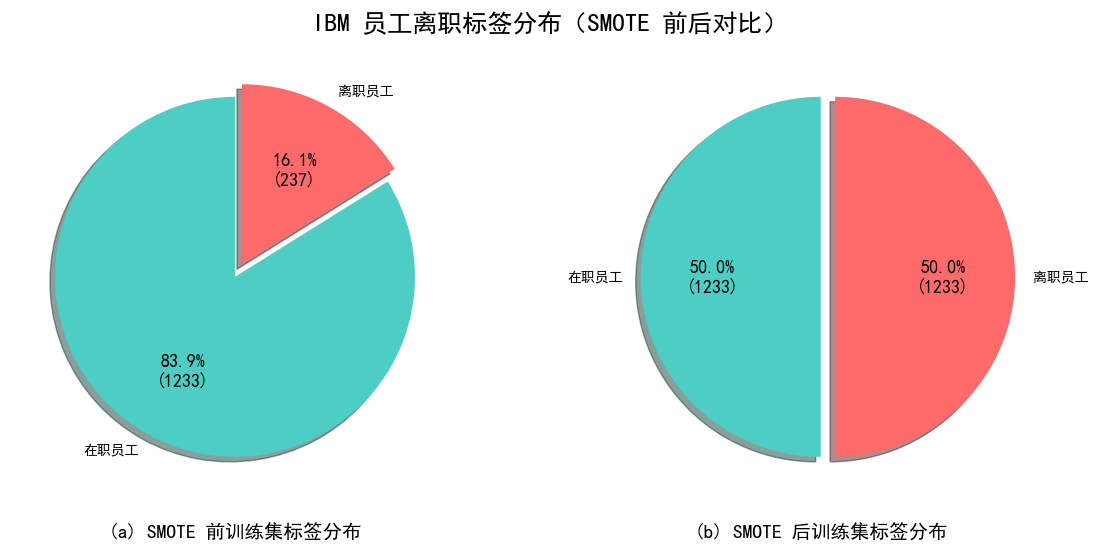

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# ===== 真实数据（SMOTE 前）=====
counts_before = pd.Series([1233, 237])  # 在职、离职

# ===== SMOTE 后数据（完全平衡）=====
counts_after = pd.Series([1233, 1233])  # 平衡数据

# 设置全局中文和样式
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 标签 & 颜色
labels = ['在职员工', '离职员工']
colors = ['#4ECDC4', '#FF6B6B']  # 青色 / 红色

# ====== 自定义函数：显示百分比和数量 ======
def autopct_format(counts):
    def my_format(pct):
        total = sum(counts)
        count = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n({count})"
    return my_format

# ===== 绘图函数 =====
def plot_pie(ax, counts, title):
    wedges, texts, autotexts = ax.pie(
        counts.values,
        labels=labels,
        colors=colors,
        autopct=autopct_format(counts),  # 自定义格式
        startangle=90,
        explode=(0, 0.08),
        shadow=True
    )
    # 数字美化
    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(13)
    # 标题放在图下方
    ax.set_xlabel(title, fontsize=14, fontweight='bold', labelpad=15)

# ===== 创建画布 =====
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('IBM 员工离职标签分布（SMOTE 前后对比）', fontsize=18, fontweight='bold', y=0.92)

# SMOTE 前
plot_pie(axes[0], counts_before, '(a) SMOTE 前训练集标签分布')
# SMOTE 后
plot_pie(axes[1], counts_after, '(b) SMOTE 后训练集标签分布')

plt.tight_layout()
plt.subplots_adjust(top=0.85, bottom=0.1)

# ===== 保存高清图片 =====
output_dir = "图片文件"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "smote_before_after.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"图片已保存到: {output_path}")

plt.show()


# 第三步：数据可视化

1. 单特征分布图：展示每个特征自身的数据分布。
2. 特征与标签关系图：探索关键特征与“是否离职”之间的关系。
3. 相关性热力图：分析数值特征之间的线性关系。


In [6]:
# 导入绘图库
import matplotlib.pyplot as plt
import seaborn as sns

# 设置全局绘图风格
sns.set_style("whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']  # 'SimHei' 是黑体，适用于Windows/Linux
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题


连续变量适合做小提琴图或者箱线图，离散变量适合做直方图

连续变量图已保存到: 图片文件\连续变量_与离职关系.png


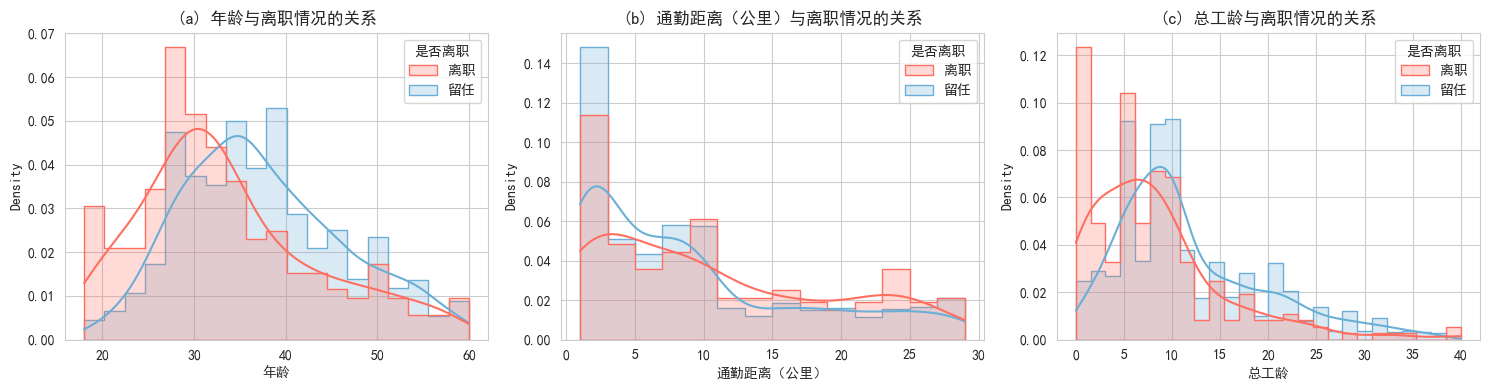

离散变量图已保存到: 图片文件\离散变量_与离职关系.png


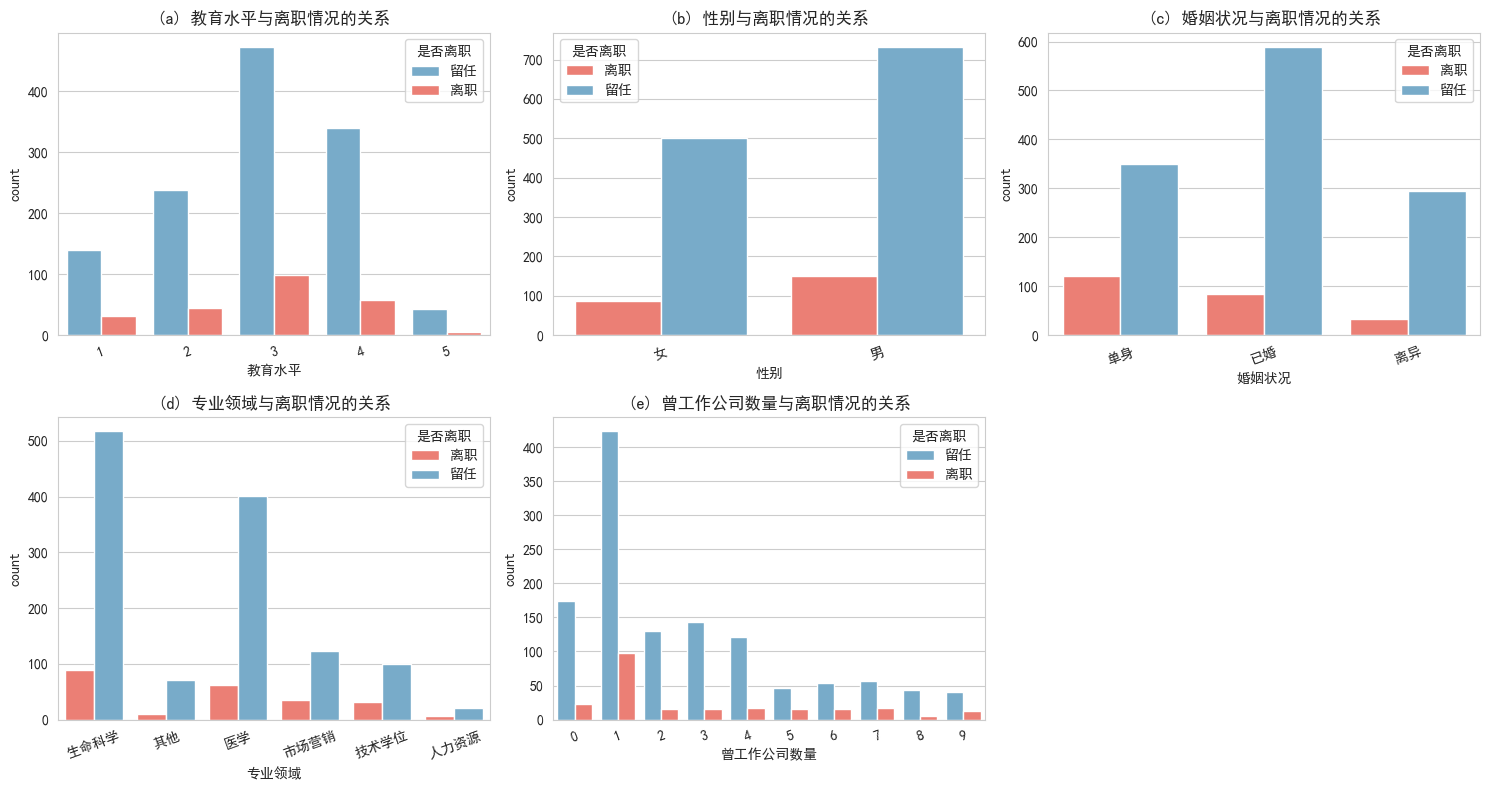

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os  # 导入 os

# ========== 创建保存目录 ==========
output_dir = "图片文件"
os.makedirs(output_dir, exist_ok=True)

# ========== 读取数据 + 列名映射 ==========
df = pd.read_csv(r"data\WA_Fn-UseC_-HR-Employee-Attrition.csv")

col_map = {
    "Age": "年龄",
    "Gender": "性别",
    "MaritalStatus": "婚姻状况",
    "DistanceFromHome": "通勤距离（公里）",
    "Education": "教育水平",
    "EducationField": "专业领域",
    "NumCompaniesWorked": "曾工作公司数量",
    "TotalWorkingYears": "总工龄",
    "Attrition": "是否离职"
}
df = df.rename(columns=col_map)

# 值映射
df["是否离职"] = df["是否离职"].map({"Yes": "离职", "No": "留任"})
df["性别"] = df["性别"].map({"Male": "男", "Female": "女"})
df["婚姻状况"] = df["婚姻状况"].map({"Single": "单身", "Married": "已婚", "Divorced": "离异"})
df["专业领域"] = df["专业领域"].map({
    "Life Sciences": "生命科学",
    "Medical": "医学",
    "Marketing": "市场营销",
    "Technical Degree": "技术学位",
    "Other": "其他",
    "Human Resources": "人力资源"
})

# 配色
palette = {"离职": "#FF6F61", "留任": "#6BAED6"}

# ================================
# 连续变量
cont_vars = ["年龄", "通勤距离（公里）", "总工龄"]
labels_cont = ['(a)', '(b)', '(c)']

fig1, axes1 = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(cont_vars):
    sns.histplot(data=df, x=col, hue="是否离职",
                 kde=True, palette=palette, ax=axes1[i],
                 element="step", stat="density", common_norm=False)
    axes1[i].set_title(f"{labels_cont[i]} {col}与离职情况的关系", fontsize=12)

plt.tight_layout()
output_path1 = os.path.join(output_dir, "连续变量_与离职关系.png")
fig1.savefig(output_path1, dpi=300, bbox_inches="tight")
print(f"连续变量图已保存到: {output_path1}")
plt.show()

# ================================
# 离散变量
disc_vars = ["教育水平", "性别", "婚姻状况", "专业领域", "曾工作公司数量"]
labels_disc = ['(a)', '(b)', '(c)', '(d)', '(e)']

fig2, axes2 = plt.subplots(2, 3, figsize=(15, 8))
axes2 = axes2.flatten()

for i, col in enumerate(disc_vars):
    if col == "教育水平":
        order = sorted(df[col].unique())
        sns.countplot(x=col, data=df, hue="是否离职",
                      order=order, palette=palette, ax=axes2[i])
    else:
        sns.countplot(x=col, data=df, hue="是否离职",
                      palette=palette, ax=axes2[i])
    axes2[i].set_title(f"{labels_disc[i]} {col}与离职情况的关系", fontsize=12)
    axes2[i].tick_params(axis='x', rotation=20)

# 删除多余子图
for j in range(len(disc_vars), len(axes2)):
    fig2.delaxes(axes2[j])

plt.tight_layout()
output_path2 = os.path.join(output_dir, "离散变量_与离职关系.png")
fig2.savefig(output_path2, dpi=300, bbox_inches="tight")
print(f"离散变量图已保存到: {output_path2}")
plt.show()


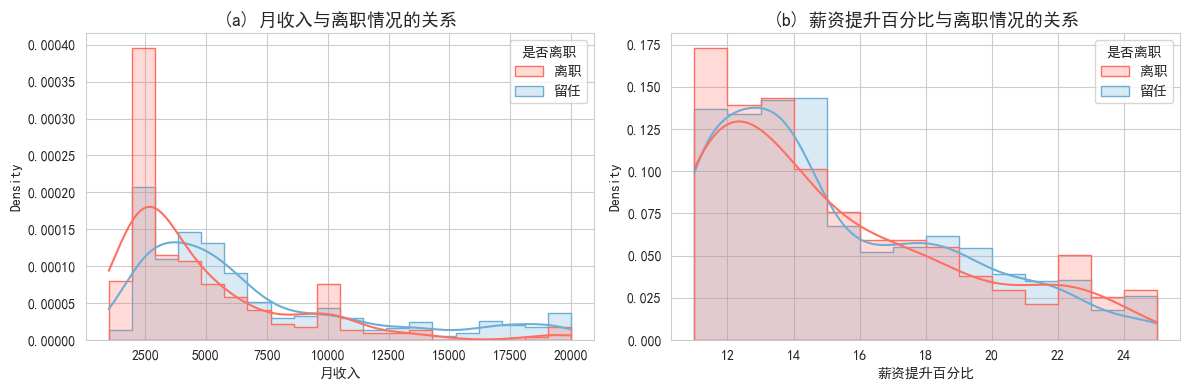

连续变量图已保存到: 图片文件\工作与薪酬_连续变量.png


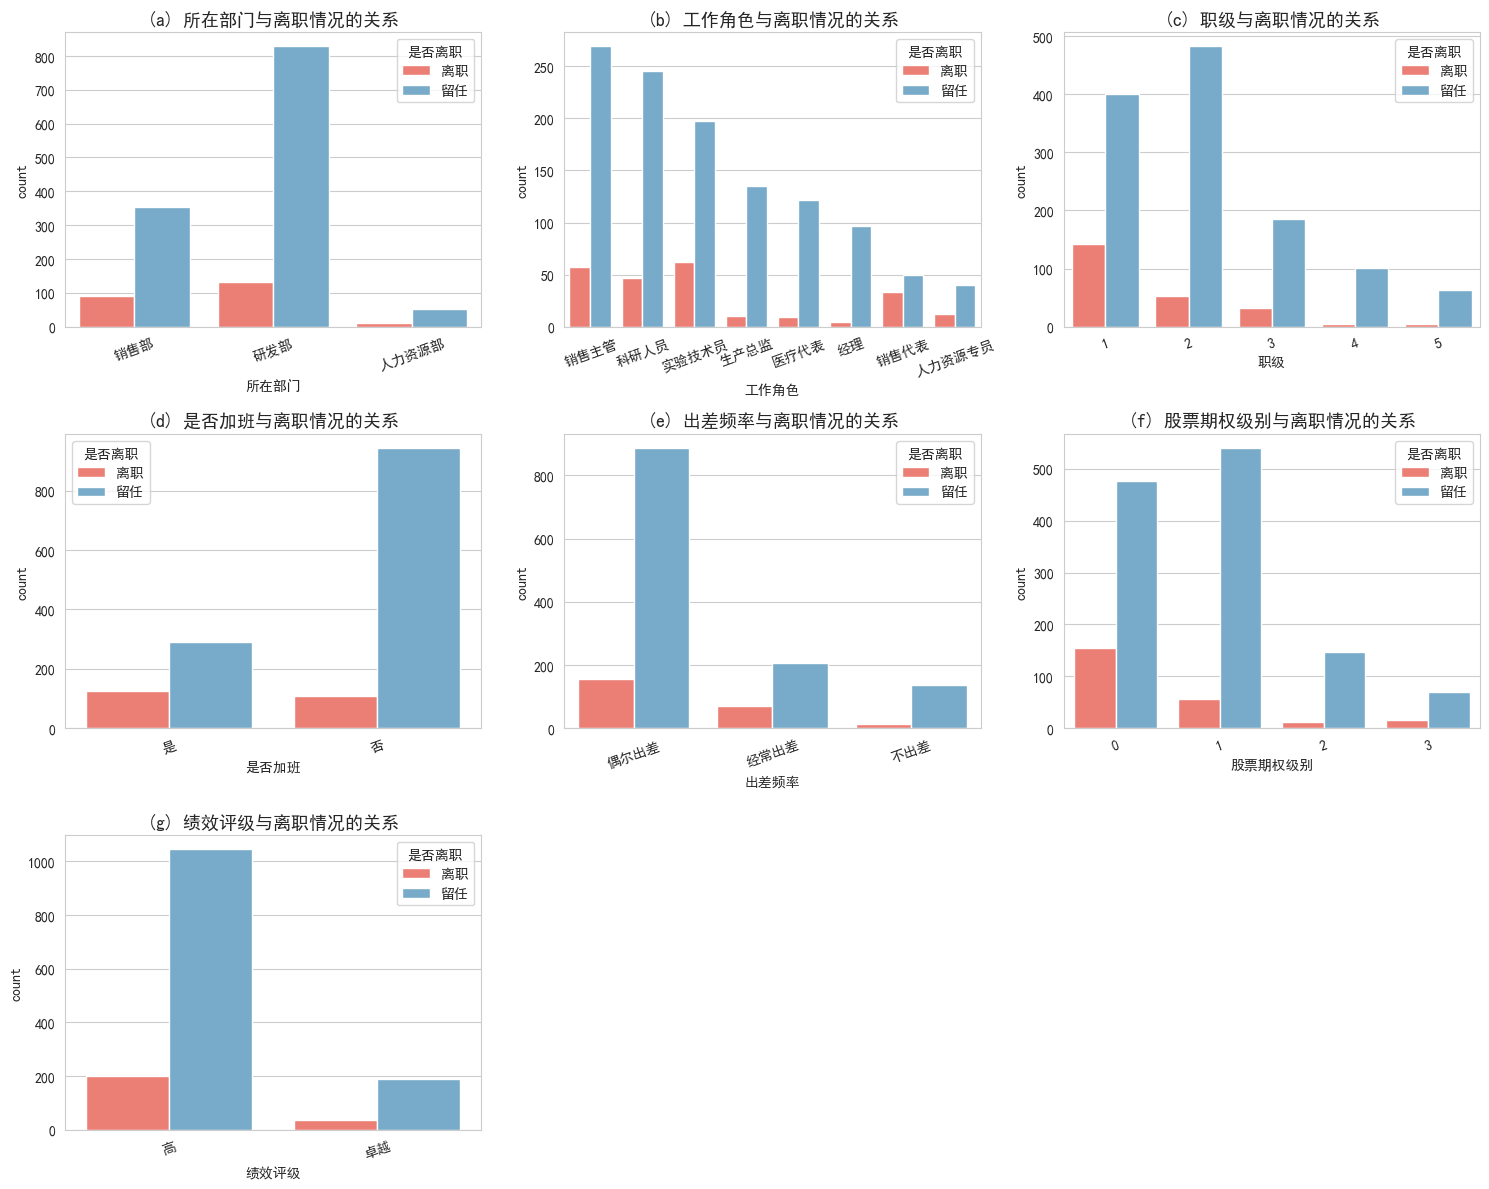

离散变量图已保存到: 图片文件\工作与薪酬_离散变量.png


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 创建保存目录
output_dir = "图片文件"
os.makedirs(output_dir, exist_ok=True)

# 读取数据
df = pd.read_csv(r"data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

# --- 列名映射（中文化特征名） ---
col_map = {
    "Department": "所在部门",
    "JobRole": "工作角色",
    "JobLevel": "职级",
    "OverTime": "是否加班",
    "BusinessTravel": "出差频率",
    "MonthlyIncome": "月收入",
    "StockOptionLevel": "股票期权级别",
    "PercentSalaryHike": "薪资提升百分比",
    "PerformanceRating": "绩效评级",
    "Attrition": "是否离职"
}
df.rename(columns=col_map, inplace=True)

# --- 值映射（取值中文化） ---
# 是否离职
df["是否离职"] = df["是否离职"].map({
    "Yes": "离职",
    "No": "留任"
})

# 部门
df["所在部门"] = df["所在部门"].map({
    "Sales": "销售部",
    "Research & Development": "研发部",
    "Human Resources": "人力资源部"
})

# 工作角色
df["工作角色"] = df["工作角色"].map({
    "Sales Executive": "销售主管",
    "Research Scientist": "科研人员",
    "Laboratory Technician": "实验技术员",
    "Manufacturing Director": "生产总监",
    "Healthcare Representative": "医疗代表",
    "Manager": "经理",
    "Sales Representative": "销售代表",
    "Human Resources": "人力资源专员"
})

# 是否加班
df["是否加班"] = df["是否加班"].map({
    "Yes": "是",
    "No": "否"
})

# 出差频率
df["出差频率"] = df["出差频率"].map({
    "Non-Travel": "不出差",
    "Travel_Rarely": "偶尔出差",
    "Travel_Frequently": "经常出差"
})

# 绩效评级
df["绩效评级"] = df["绩效评级"].map({
    1: "低",
    2: "一般",
    3: "高",
    4: "卓越"
})

palette = {"离职": "#FF6F61", "留任": "#6BAED6"}

# -------------------------
# 连续变量绘制
cont_vars = ["月收入", "薪资提升百分比"]
labels_cont = ['(a)', '(b)']

fig1, axes1 = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(cont_vars):
    sns.histplot(data=df, x=col, hue="是否离职",
                 kde=True, palette=palette, ax=axes1[i],
                 element="step", stat="density", common_norm=False)
    axes1[i].set_title(f"{labels_cont[i]} {col}与离职情况的关系", fontsize=13)

plt.tight_layout()
output_path1 = os.path.join(output_dir, "工作与薪酬_连续变量.png")
fig1.savefig(output_path1, dpi=300, bbox_inches="tight")
plt.show()
print(f"连续变量图已保存到: {output_path1}")

# -------------------------
# 离散变量绘制
disc_vars = ["所在部门", "工作角色", "职级", "是否加班", "出差频率", "股票期权级别", "绩效评级"]
labels_disc = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)']

fig2, axes2 = plt.subplots(3, 3, figsize=(15, 12))
axes2 = axes2.flatten()

for i, col in enumerate(disc_vars):
    sns.countplot(x=col, data=df, hue="是否离职", palette=palette, ax=axes2[i])
    axes2[i].set_title(f"{labels_disc[i]} {col}与离职情况的关系", fontsize=13)
    axes2[i].tick_params(axis='x', rotation=20)

# 删除多余子图
for j in range(len(disc_vars), len(axes2)):
    fig2.delaxes(axes2[j])

plt.tight_layout()
output_path2 = os.path.join(output_dir, "工作与薪酬_离散变量.png")
fig2.savefig(output_path2, dpi=300, bbox_inches="tight")
plt.show()
print(f"离散变量图已保存到: {output_path2}")


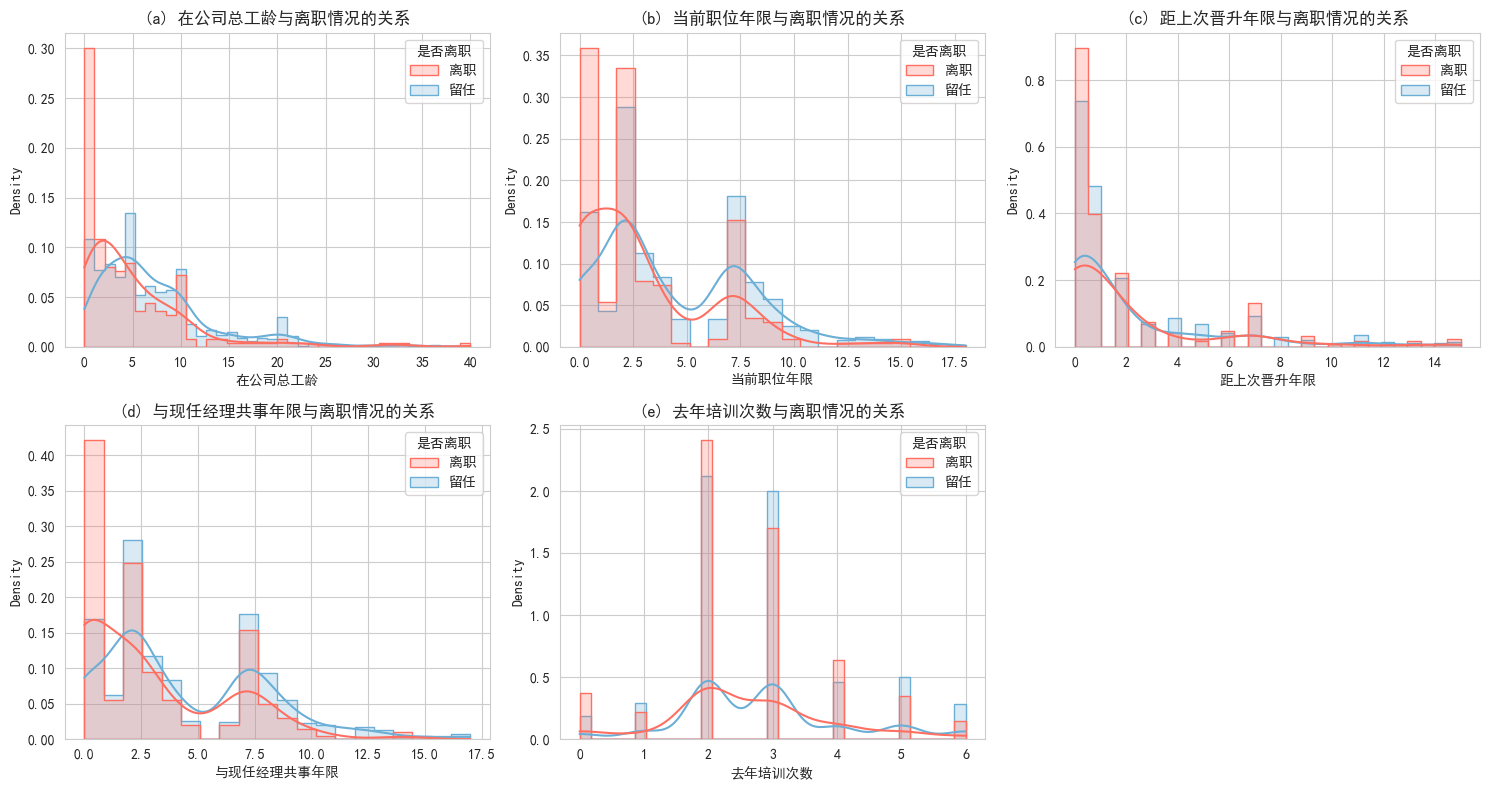

连续变量图已保存到: 图片文件\在职情况满意度_连续变量.png


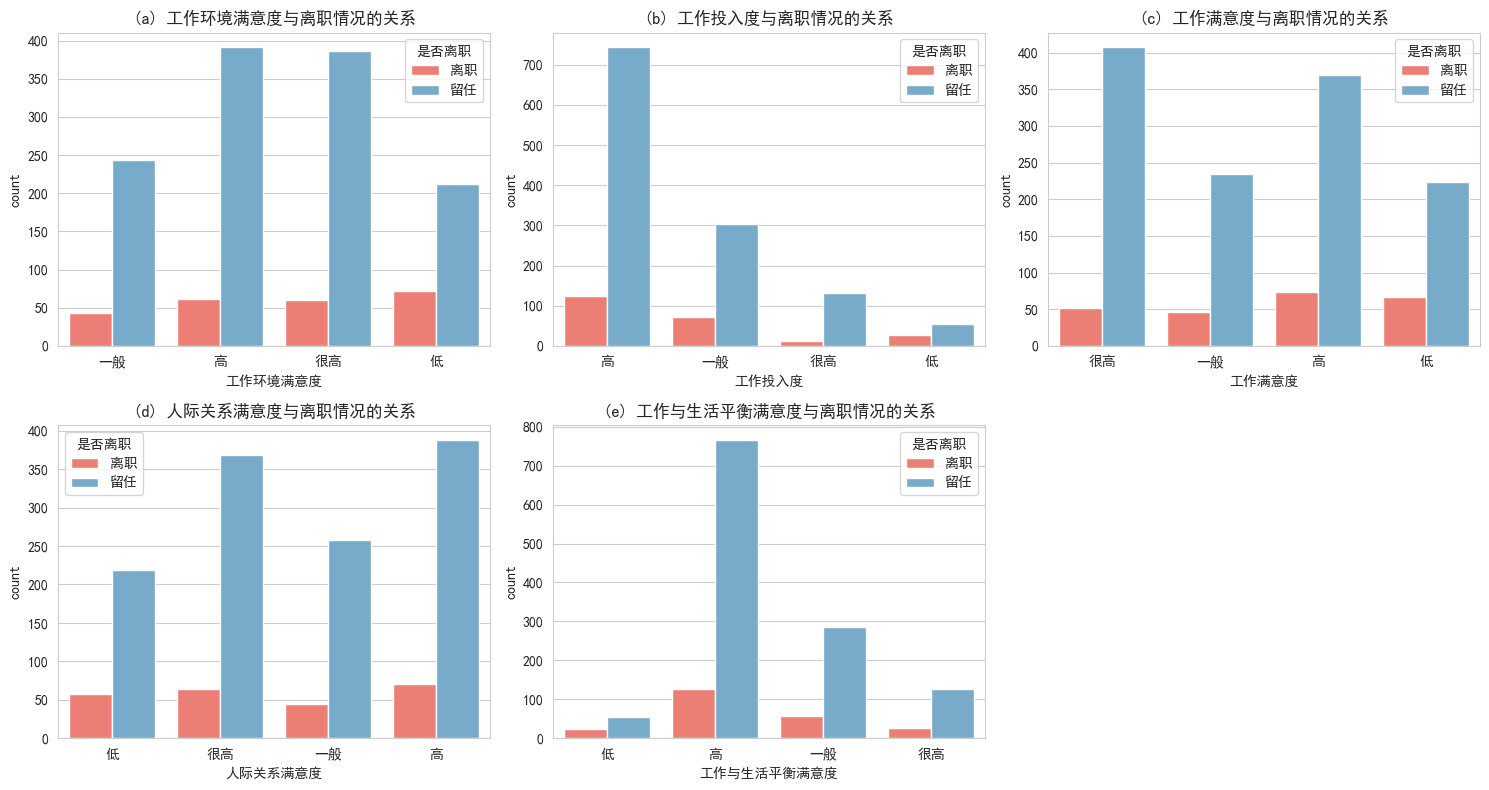

离散变量图已保存到: 图片文件\在职情况满意度_离散变量.png


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 创建保存目录
output_dir = "图片文件"
os.makedirs(output_dir, exist_ok=True)

# 读取数据
df = pd.read_csv(r"data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

# ---------------------
# 列名映射 中文化
col_map = {
    "YearsAtCompany": "在公司总工龄",
    "YearsInCurrentRole": "当前职位年限",
    "YearsSinceLastPromotion": "距上次晋升年限",
    "YearsWithCurrManager": "与现任经理共事年限",
    "TrainingTimesLastYear": "去年培训次数",
    "EnvironmentSatisfaction": "工作环境满意度",
    "JobInvolvement": "工作投入度",
    "JobSatisfaction": "工作满意度",
    "RelationshipSatisfaction": "人际关系满意度",
    "WorkLifeBalance": "工作与生活平衡满意度",
    "Attrition": "是否离职"
}
df.rename(columns=col_map, inplace=True)

# 离职映射
df["是否离职"] = df["是否离职"].map({"Yes": "离职", "No": "留任"})

# 满意度映射（1-4）
satisfaction_map = {
    1: "低", 2: "一般", 3: "高", 4: "很高"
}
for col in ["工作环境满意度","工作投入度",
            "工作满意度","人际关系满意度","工作与生活平衡满意度"]:
    df[col] = df[col].map(satisfaction_map)

palette = {"离职": "#FF6F61", "留任": "#6BAED6"}

# ---------------------
# 连续变量
cont_vars = [
    "在公司总工龄", "当前职位年限",
    "距上次晋升年限", "与现任经理共事年限", "去年培训次数"
]
labels_cont = ['(a)', '(b)', '(c)', '(d)', '(e)']

fig1, axes1 = plt.subplots(2, 3, figsize=(15, 8))
axes1 = axes1.flatten()

for i, col in enumerate(cont_vars):
    sns.histplot(data=df, x=col, hue="是否离职",
                 kde=True, palette=palette, ax=axes1[i],
                 element="step", stat="density", common_norm=False)
    axes1[i].set_title(f"{labels_cont[i]} {col}与离职情况的关系", fontsize=12)

# 删除空子图
for j in range(len(cont_vars), len(axes1)):
    fig1.delaxes(axes1[j])

plt.tight_layout()
output_path1 = os.path.join(output_dir, "在职情况满意度_连续变量.png")
fig1.savefig(output_path1, dpi=300, bbox_inches="tight")
plt.show()
print(f"连续变量图已保存到: {output_path1}")

# ---------------------
# 离散变量
disc_vars = [
    "工作环境满意度", "工作投入度",
    "工作满意度", "人际关系满意度", "工作与生活平衡满意度"
]
labels_disc = ['(a)', '(b)', '(c)', '(d)', '(e)']

fig2, axes2 = plt.subplots(2, 3, figsize=(15, 8))
axes2 = axes2.flatten()

for i, col in enumerate(disc_vars):
    sns.countplot(x=col, data=df, hue="是否离职",
                  palette=palette, ax=axes2[i])
    axes2[i].set_title(f"{labels_disc[i]} {col}与离职情况的关系", fontsize=12)

# 删除空图
for j in range(len(disc_vars), len(axes2)):
    fig2.delaxes(axes2[j])

plt.tight_layout()
output_path2 = os.path.join(output_dir, "在职情况满意度_离散变量.png")
fig2.savefig(output_path2, dpi=300, bbox_inches="tight")
plt.show()
print(f"离散变量图已保存到: {output_path2}")


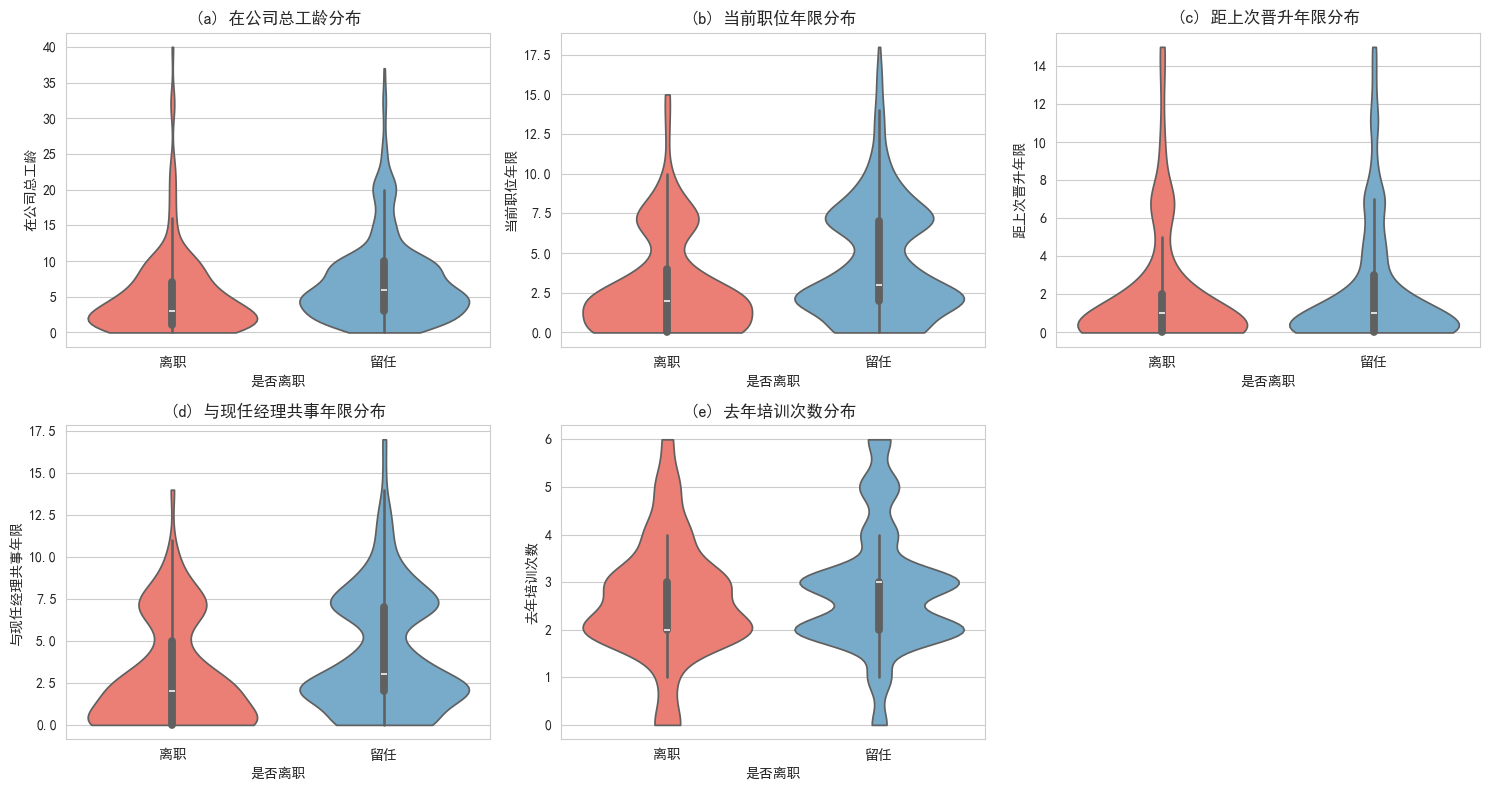

连续变量（小提琴图）已保存到: 图片文件\在职情况满意度_连续变量_小提琴图.png


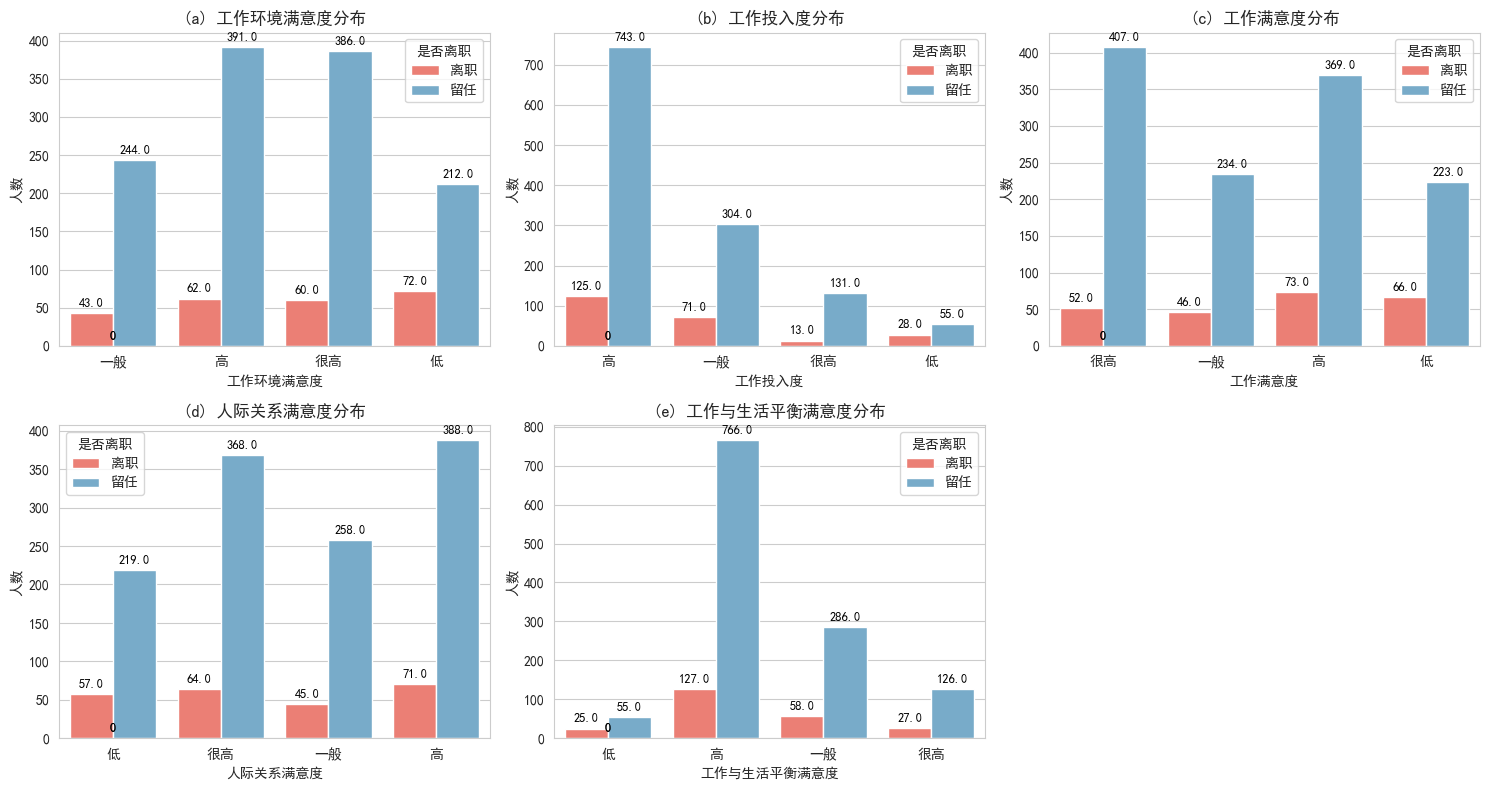

离散变量（带数值）图已保存到: 图片文件\在职情况满意度_离散变量_条形数值图.png


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 创建保存目录
output_dir = "图片文件"
os.makedirs(output_dir, exist_ok=True)

# 读取数据
df = pd.read_csv(r"data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

# 列名映射 中文化
col_map = {
    "YearsAtCompany": "在公司总工龄",
    "YearsInCurrentRole": "当前职位年限",
    "YearsSinceLastPromotion": "距上次晋升年限",
    "YearsWithCurrManager": "与现任经理共事年限",
    "TrainingTimesLastYear": "去年培训次数",
    "EnvironmentSatisfaction": "工作环境满意度",
    "JobInvolvement": "工作投入度",
    "JobSatisfaction": "工作满意度",
    "RelationshipSatisfaction": "人际关系满意度",
    "WorkLifeBalance": "工作与生活平衡满意度",
    "Attrition": "是否离职"
}
df.rename(columns=col_map, inplace=True)

# 是否离职映射
df["是否离职"] = df["是否离职"].map({"Yes": "离职", "No": "留任"})

# 满意度映射（1-4 对应 低 一般 高 很高）
satisfaction_map = {1: "低", 2: "一般", 3: "高", 4: "很高"}
for col in ["工作环境满意度", "工作投入度", "工作满意度", "人际关系满意度", "工作与生活平衡满意度"]:
    df[col] = df[col].map(satisfaction_map)

palette = {"离职": "#FF6F61", "留任": "#6BAED6"}

# ---------------------
# 连续变量 -> 小提琴图
cont_vars = ["在公司总工龄", "当前职位年限", "距上次晋升年限", "与现任经理共事年限", "去年培训次数"]
labels_cont = ['(a)', '(b)', '(c)', '(d)', '(e)']

fig1, axes1 = plt.subplots(2, 3, figsize=(15, 8))
axes1 = axes1.flatten()

for i, col in enumerate(cont_vars):
    sns.violinplot(
        data=df, x="是否离职", y=col, palette=palette,
        ax=axes1[i], cut=0
    )
    axes1[i].set_title(f"{labels_cont[i]} {col}分布", fontsize=12)
    axes1[i].set_xlabel("是否离职")
    axes1[i].set_ylabel(col)

# 删除多余空子图
for j in range(len(cont_vars), len(axes1)):
    fig1.delaxes(axes1[j])

plt.tight_layout()
output_path1 = os.path.join(output_dir, "在职情况满意度_连续变量_小提琴图.png")
fig1.savefig(output_path1, dpi=300, bbox_inches="tight")
plt.show()
print(f"连续变量（小提琴图）已保存到: {output_path1}")

# ---------------------
# 离散变量 -> countplot 直方，并加数值
disc_vars = ["工作环境满意度", "工作投入度", "工作满意度", "人际关系满意度", "工作与生活平衡满意度"]
labels_disc = ['(a)', '(b)', '(c)', '(d)', '(e)']

fig2, axes2 = plt.subplots(2, 3, figsize=(15, 8))
axes2 = axes2.flatten()

for i, col in enumerate(disc_vars):
    ax = axes2[i]
    g = sns.countplot(
        x=col, data=df, hue="是否离职",
        palette=palette, ax=ax
    )
    ax.set_title(f"{labels_disc[i]} {col}分布", fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel("人数")

    # 在条形上添加数值标签
    for p in g.patches:
        height = p.get_height()
        ax.annotate(f"{height}",
                    (p.get_x() + p.get_width() / 2., height),
                    ha="center", va="bottom", fontsize=9, color="black", xytext=(0, 3),
                    textcoords="offset points")

# 删除多余空子图
for j in range(len(disc_vars), len(axes2)):
    fig2.delaxes(axes2[j])

plt.tight_layout()
output_path2 = os.path.join(output_dir, "在职情况满意度_离散变量_条形数值图.png")
fig2.savefig(output_path2, dpi=300, bbox_inches="tight")
plt.show()
print(f"离散变量（带数值）图已保存到: {output_path2}")


## 3.1 单特征分布图
这里，我们将为所有原始数值特征和原始类别特征绘制分布图。我们使用预处理前的数据框 df 来绘图，这样可以展示最原始、最直观的特征分布。

原始训练集中标签分布:
是否离职
0    986
1    190
Name: count, dtype: int64

SMOTE 处理后训练集中标签分布:
是否离职
0    986
1    986
Name: count, dtype: int64

数据预处理完成，X_train_smote, y_train_smote, X_test, y_test 已准备好。
==================== 数值特征分布图 ====================


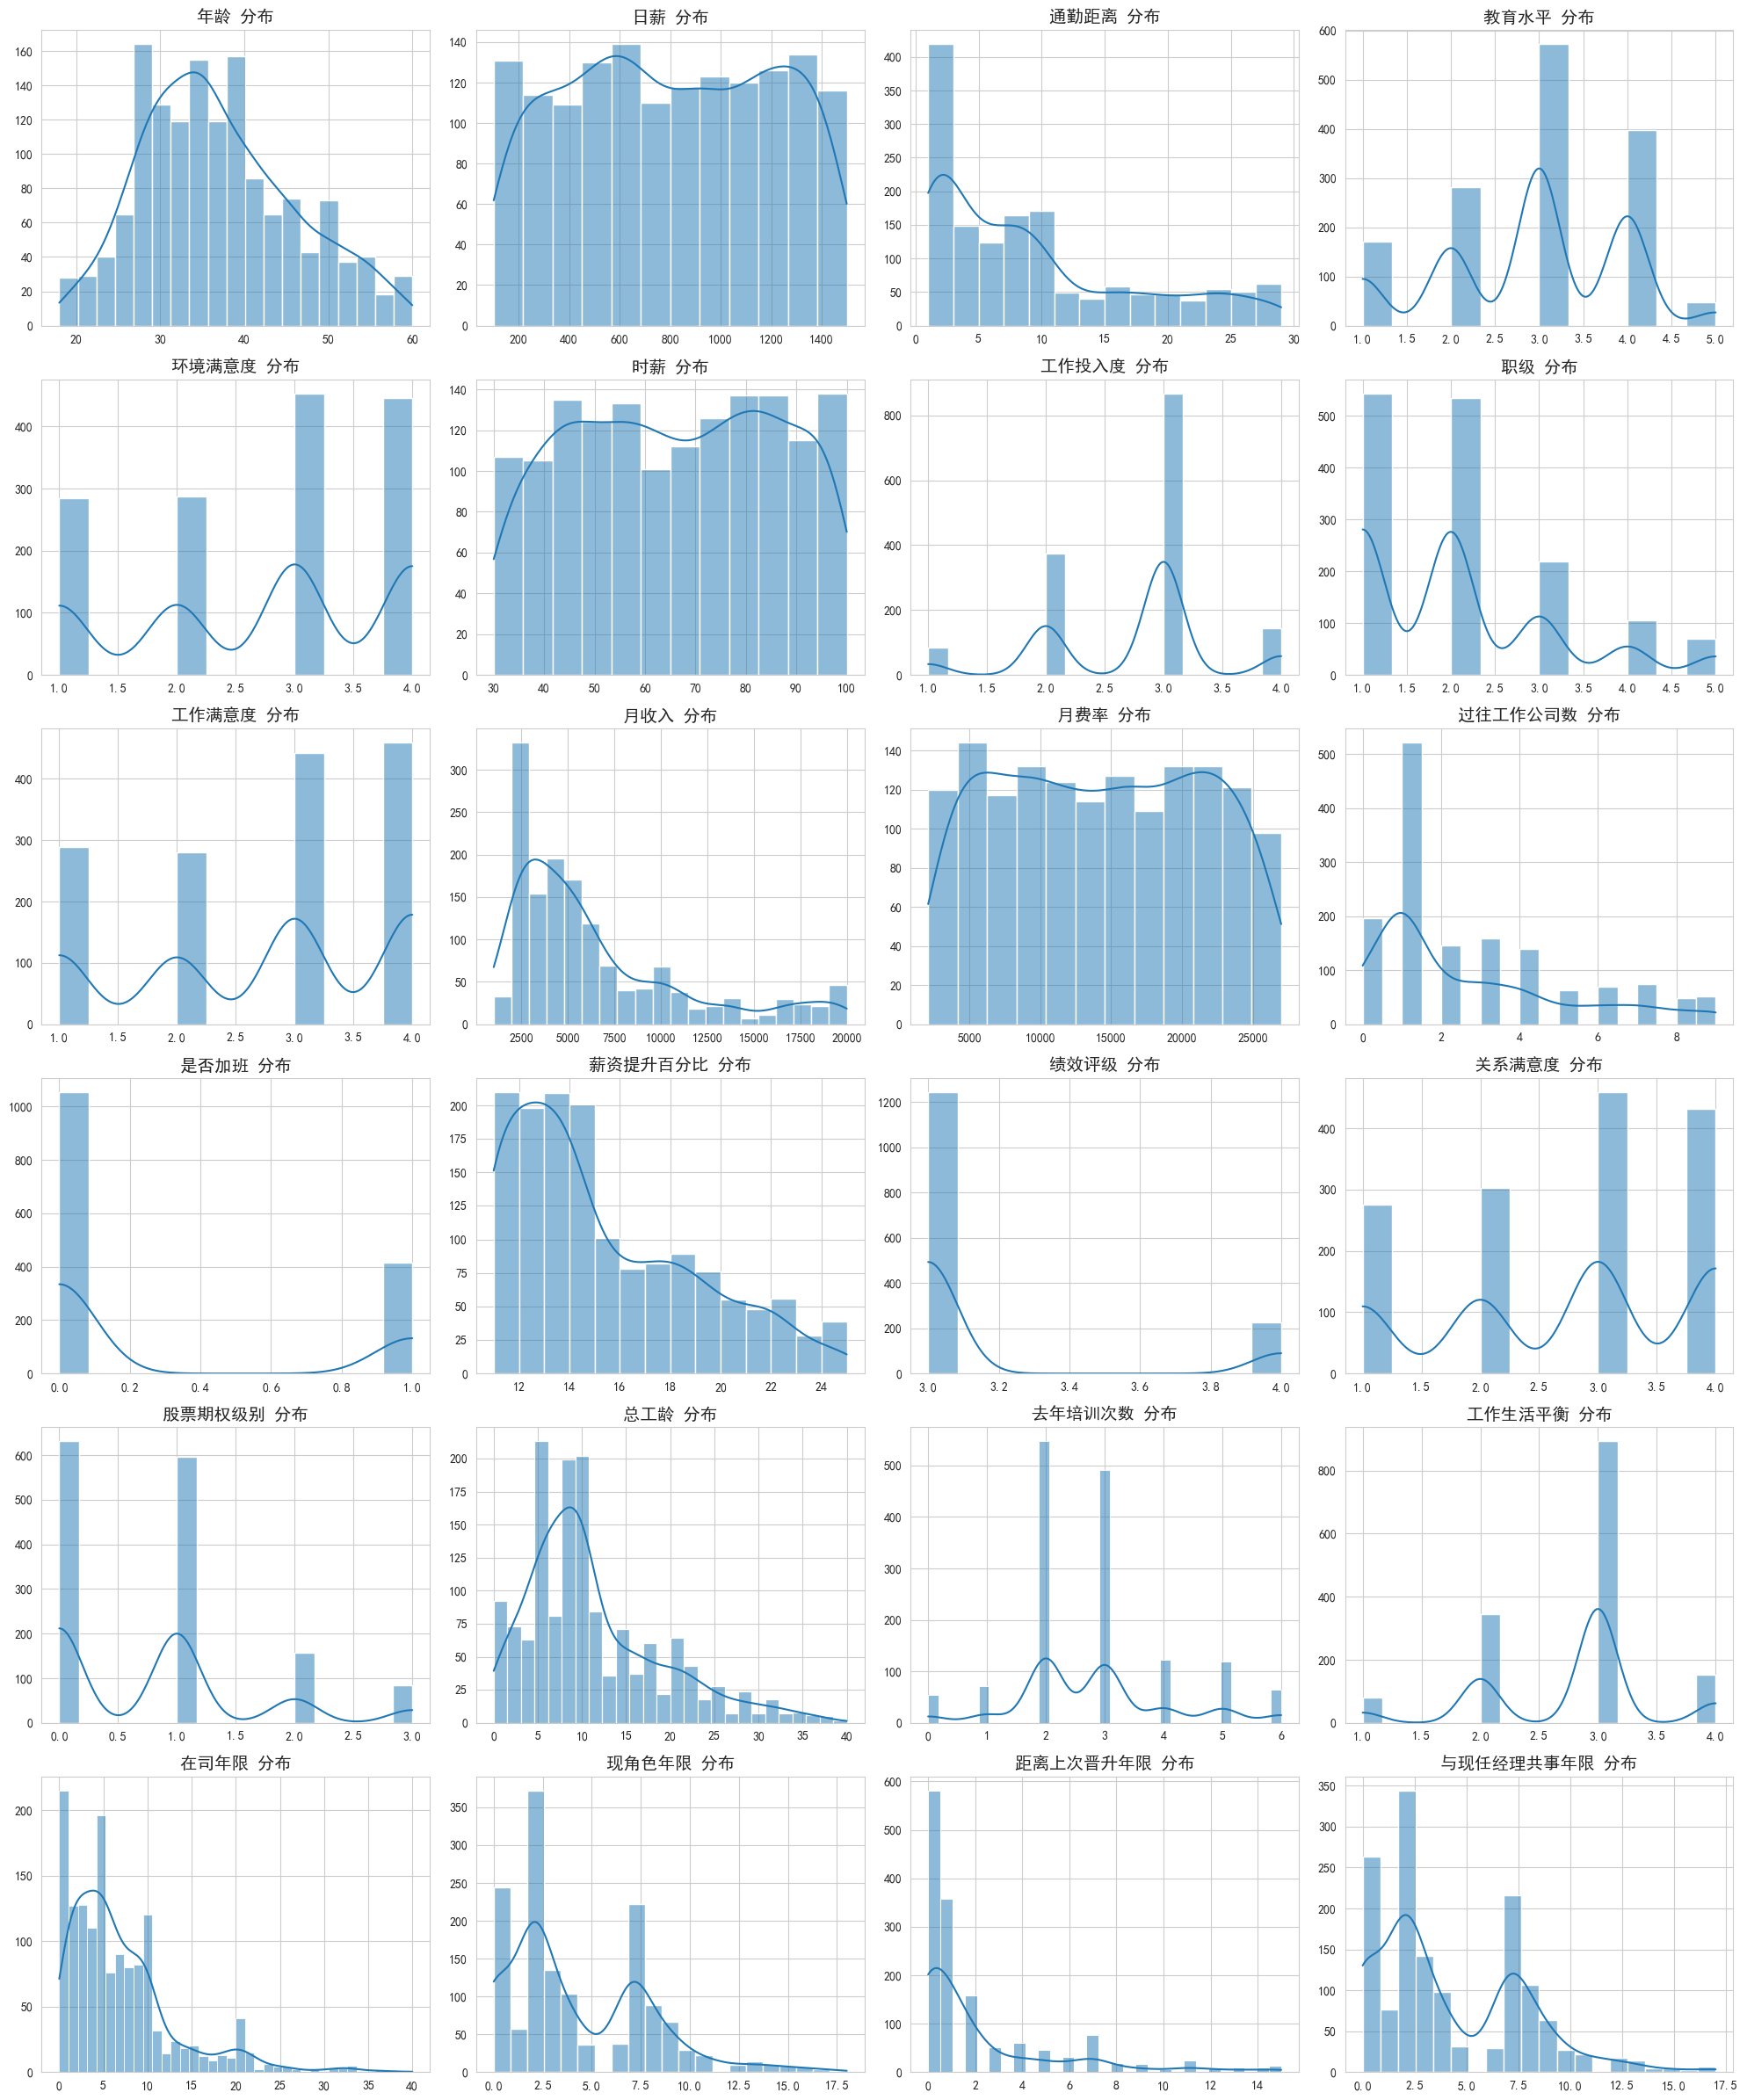


==================== 类别特征分布图 ====================


ValueError: Number of rows must be a positive integer, not 0

<Figure size 2000x0 with 0 Axes>

In [12]:
# 从预处理步骤中我们已经得到了数值和类别特征列表
# 如果没有，可以重新定义
# 假设 df 仍然是那个翻译了列名、删除了无用列的 DataFrame

import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import os

# === 1. 加载数据 ===
file_path = r'data\WA_Fn-UseC_-HR-Employee-Attrition.csv'
df = pd.read_csv(file_path)

# === 2. 特征翻译与清理 ===
feature_map = {
    'Age': '年龄', 'Attrition': '是否离职', 'BusinessTravel': '出差频率', 'DailyRate': '日薪',
    'Department': '部门', 'DistanceFromHome': '通勤距离', 'Education': '教育水平',
    'EducationField': '专业领域', 'EmployeeCount': '员工总数', 'EmployeeNumber': '员工编号',
    'EnvironmentSatisfaction': '环境满意度', 'Gender': '性别', 'HourlyRate': '时薪',
    'JobInvolvement': '工作投入度', 'JobLevel': '职级', 'JobRole': '工作角色',
    'JobSatisfaction': '工作满意度', 'MaritalStatus': '婚姻状况', 'MonthlyIncome': '月收入',
    'MonthlyRate': '月费率', 'NumCompaniesWorked': '过往工作公司数', 'Over18': '是否年满18岁',
    'OverTime': '是否加班', 'PercentSalaryHike': '薪资提升百分比', 'PerformanceRating': '绩效评级',
    'RelationshipSatisfaction': '关系满意度', 'StandardHours': '标准工时', 'StockOptionLevel': '股票期权级别',
    'TotalWorkingYears': '总工龄', 'TrainingTimesLastYear': '去年培训次数', 'WorkLifeBalance': '工作生活平衡',
    'YearsAtCompany': '在司年限', 'YearsInCurrentRole': '现角色年限', 'YearsSinceLastPromotion': '距离上次晋升年限',
    'YearsWithCurrManager': '与现任经理共事年限'
}
df.rename(columns=feature_map, inplace=True)
df.drop(['员工编号', '员工总数', '是否年满18岁', '标准工时'], axis=1, inplace=True)

# === 3. 目标变量编码 ===
df['是否离职'] = df['是否离职'].map({'Yes': 1, 'No': 0})

# === 4. Label Encoding（有序或二元特征） ===
label_encode_map = {
    '是否加班': {'No': 0, 'Yes': 1}
}
df.replace(label_encode_map, inplace=True)

# 确保以下列都是 int 类型（有序类别）
ordinal_features = [
    '教育水平', '职级', '绩效评级',
    '环境满意度', '工作投入度', '工作满意度',
    '关系满意度', '工作生活平衡'
]
df[ordinal_features] = df[ordinal_features].astype(int)

# === 5. One-Hot Encoding（无序类别特征） ===
nominal_features = ['性别', '婚姻状况', '专业领域', '部门', '工作角色', '出差频率']
df = pd.get_dummies(df, columns=nominal_features, drop_first=True)

# === 6. 分离特征与标签 ===
X = df.drop('是否离职', axis=1)
y = df['是否离职']

# === 7. 切分数据集 ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("原始训练集中标签分布:")
print(y_train.value_counts())

# === 8. SMOTE 平衡训练集 ===
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nSMOTE 处理后训练集中标签分布:")
print(y_train_smote.value_counts())

print("\n数据预处理完成，X_train_smote, y_train_smote, X_test, y_test 已准备好。")



numerical_features = df.select_dtypes(include=['int64', 'float64']).drop('是否离职', axis=1).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

# --- 绘制数值特征的分布图 (直方图) ---
print("="*20 + " 数值特征分布图 " + "="*20)
num_plots = len(numerical_features)
num_cols = 4  # 每行显示4个图
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, num_rows * 4))
axes = axes.flatten() # 将二维数组展平，方便遍历

for i, feature in enumerate(numerical_features):
    sns.histplot(df[feature], ax=axes[i], kde=True)
    axes[i].set_title(f'{feature} 分布', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# 隐藏多余的子图
for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


# --- 绘制类别特征的分布图 (计数图) ---
print("\n" + "="*20 + " 类别特征分布图 " + "="*20)
cat_plots = len(categorical_features)
num_cols = 3 # 每行显示3个图
num_rows = (cat_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, num_rows * 5))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    sns.countplot(y=feature, data=df, ax=axes[i], order = df[feature].value_counts().index)
    axes[i].set_title(f'{feature} 分布', fontsize=14)
    axes[i].set_xlabel('数量')
    axes[i].set_ylabel('')

# 隐藏多余的子图
for i in range(cat_plots, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


## 3.3: 特征与标签关系图

我们将选取几个有代表性的特征，例如 月收入、是否加班、总工龄 和 工作满意度，来分析它们与 是否离职 的关系。

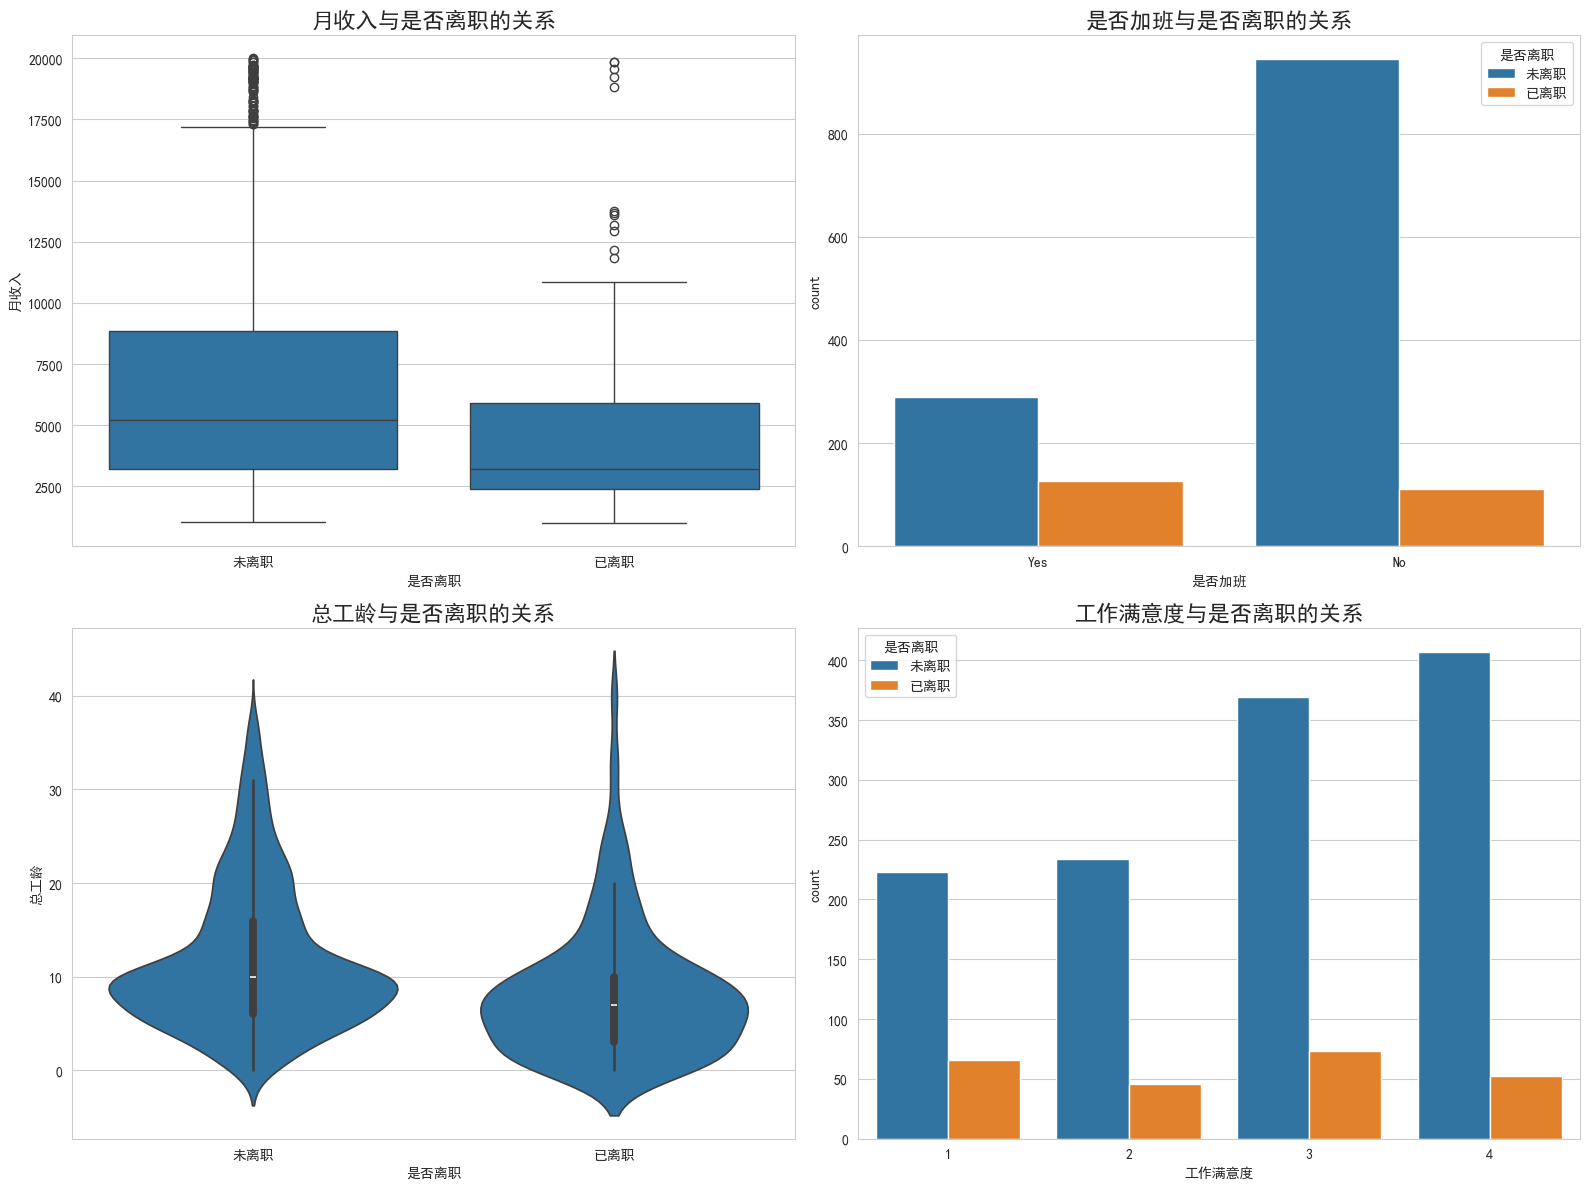

In [ ]:
# 选取几个代表性特征
selected_features = ['月收入', '是否加班', '总工龄', '工作满意度']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# 1. 月收入 vs 是否离职 (箱线图)
sns.boxplot(x='是否离职', y='月收入', data=df, ax=axes[0])
axes[0].set_title('月收入与是否离职的关系', fontsize=16)
axes[0].set_xticklabels(['未离职', '已离职'])

# 2. 是否加班 vs 是否离职 (计数图)
sns.countplot(x='是否加班', hue='是否离职', data=df, ax=axes[1])
axes[1].set_title('是否加班与是否离职的关系', fontsize=16)
# 修改图例
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, ['未离职', '已离职'], title='是否离职')

# 3. 总工龄 vs 是否离职 (小提琴图)
sns.violinplot(x='是否离职', y='总工龄', data=df, ax=axes[2])
axes[2].set_title('总工龄与是否离职的关系', fontsize=16)
axes[2].set_xticklabels(['未离职', '已离职'])

# 4. 工作满意度 vs 是否离职 (计数图)
sns.countplot(x='工作满意度', hue='是否离职', data=df, ax=axes[3])
axes[3].set_title('工作满意度与是否离职的关系', fontsize=16)
handles, labels = axes[3].get_legend_handles_labels()
axes[3].legend(handles, ['未离职', '已离职'], title='是否离职')

plt.tight_layout()
plt.show()


## 3.4: 相关性热力图

我们将计算所有数值型特征（包括标签 是否离职）之间的皮尔逊相关系数，并用热力图进行可视化。

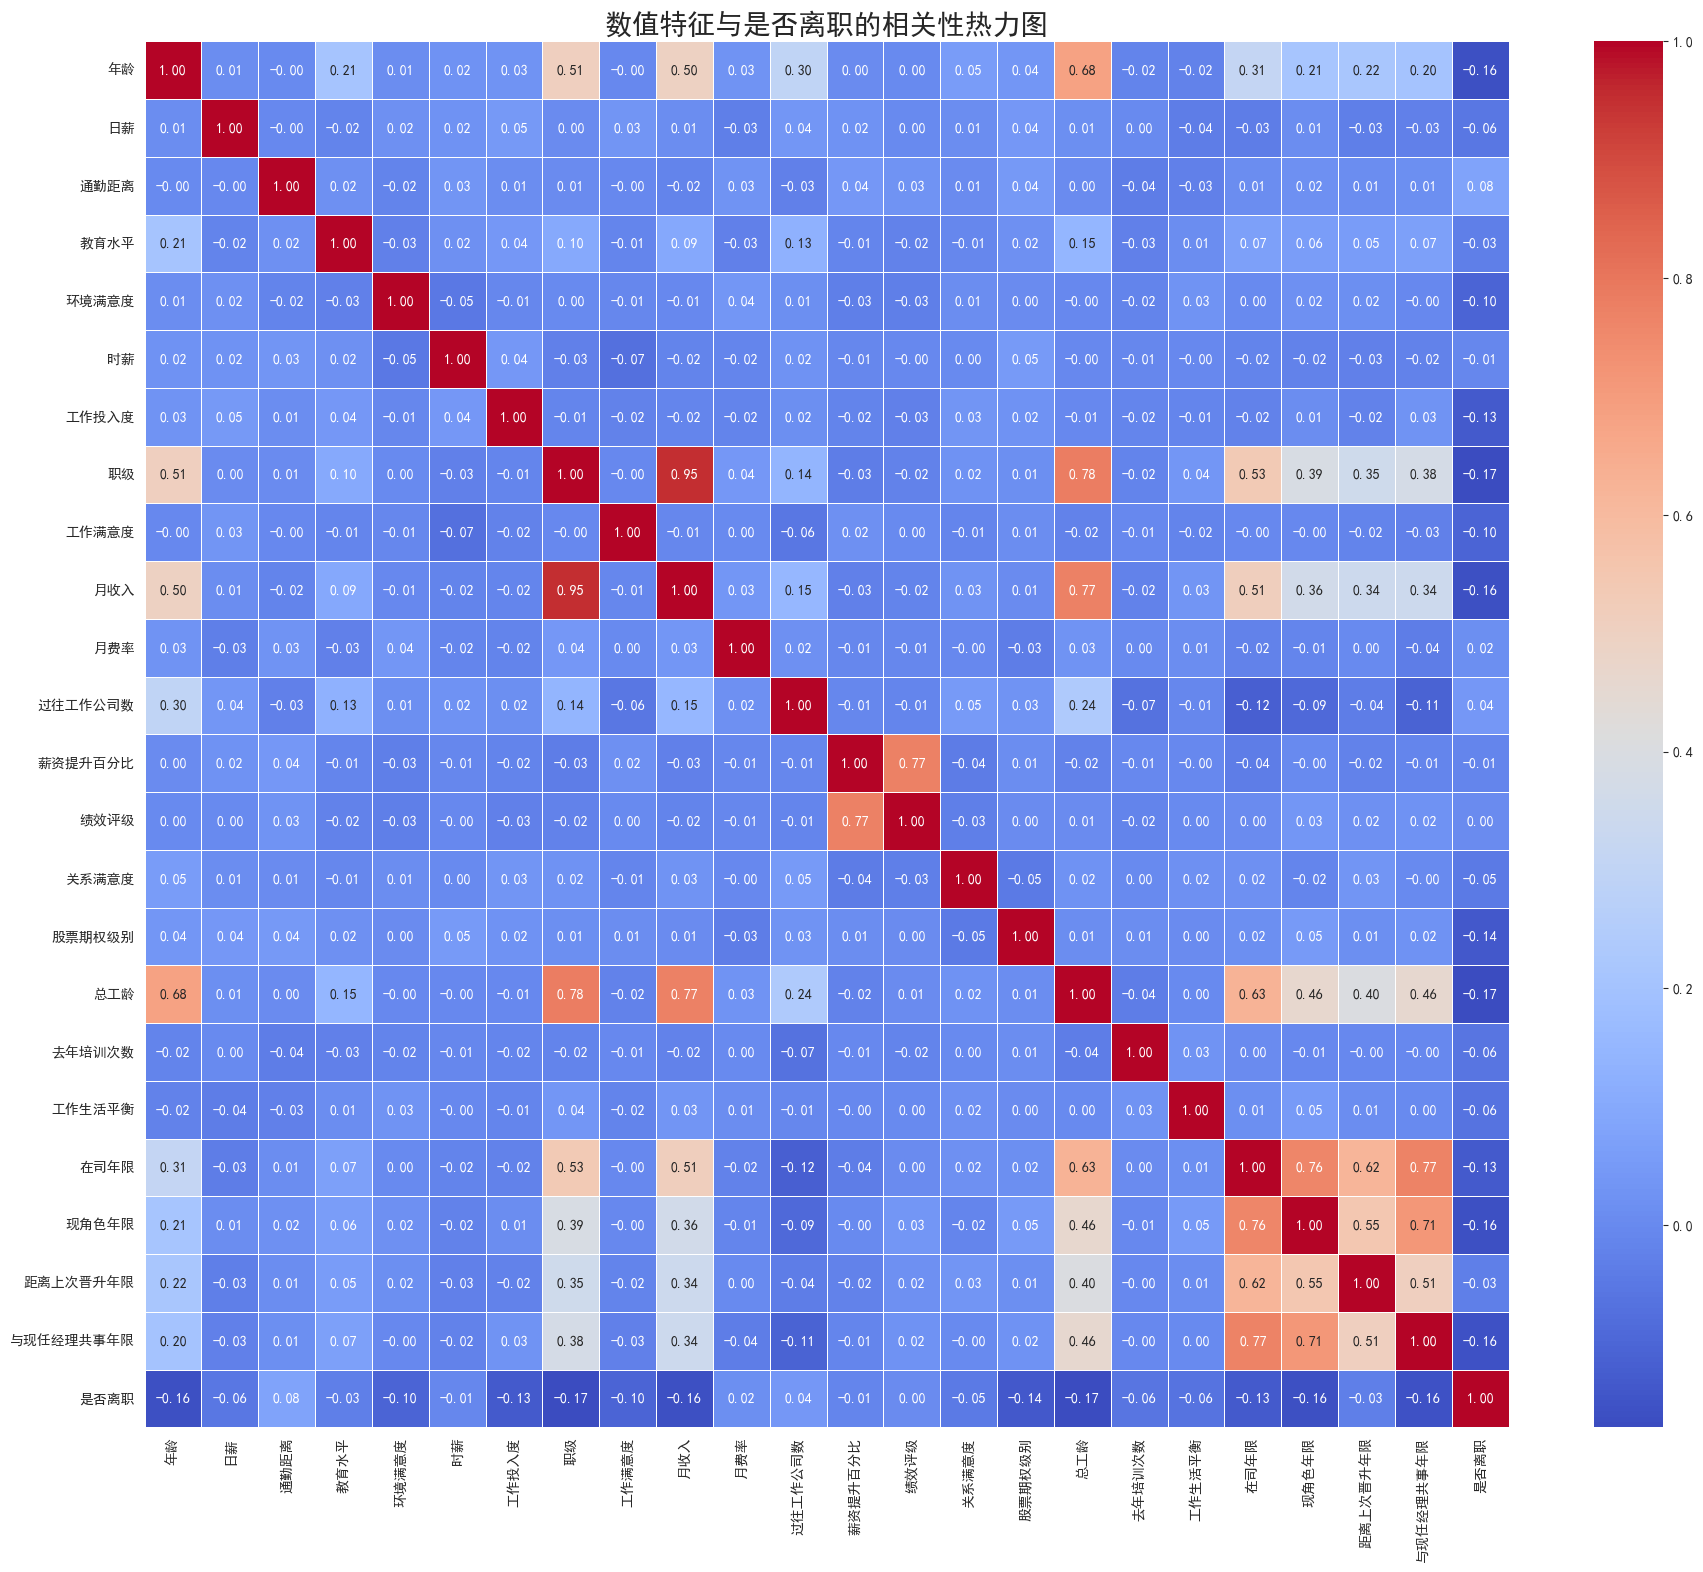

In [ ]:
# 计算数值特征（包含标签）的相关性矩阵
# 我们只选择数值型特征，因为类别特征的相关性计算方式不同
correlation_matrix = df[numerical_features + ['是否离职']].corr()

# 绘制热力图
plt.figure(figsize=(22, 18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('数值特征与是否离职的相关性热力图', fontsize=20)
plt.show()


# 四、聚类分析

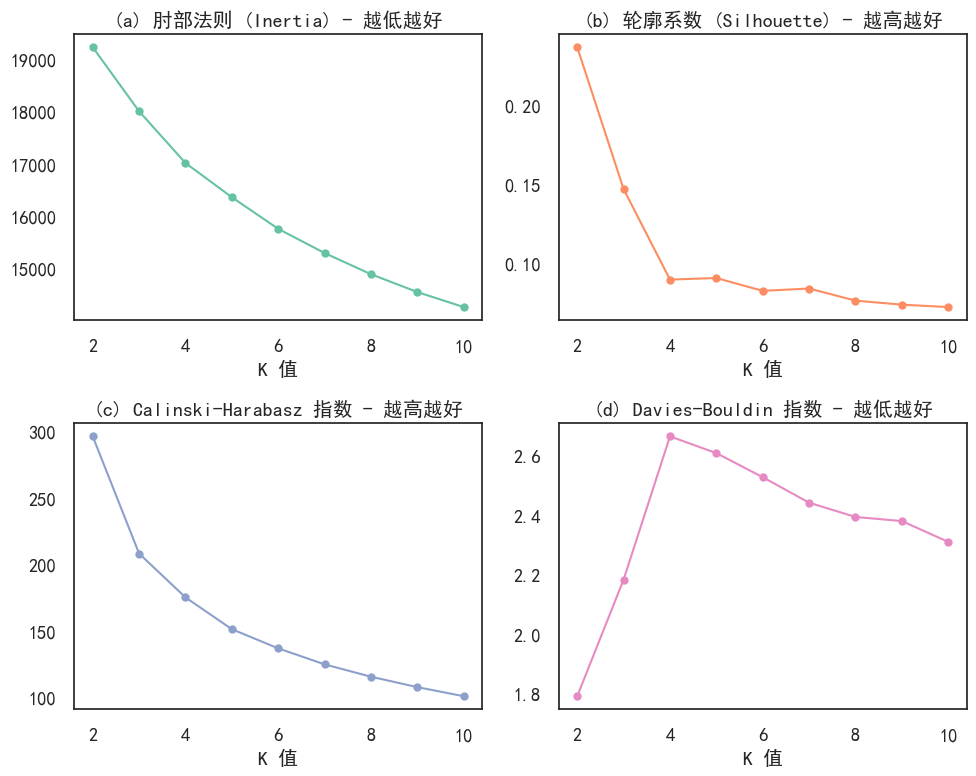

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# ======================
# 1. 读取与预处理数据
# ======================
# 创建保存目录
output_dir = "图片文件"
os.makedirs(output_dir, exist_ok=True)

# 数据路径
data_path = r"data/WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(data_path)

# ========== 特征选择（和离职最相关的） ==========
features = [
    'Age', 'DistanceFromHome', 'MonthlyIncome', 'TotalWorkingYears',
    'YearsAtCompany', 'YearsSinceLastPromotion',
    'EnvironmentSatisfaction', 'JobSatisfaction',
    'RelationshipSatisfaction', 'WorkLifeBalance',
    'PerformanceRating', 'JobLevel', 'StockOptionLevel',
    'Department', 'JobRole', 'BusinessTravel', 'EducationField', 'MaritalStatus'
]

df_selected = df[features].copy()

# 识别数值型 / 类别型特征
numeric_features = [
    'Age', 'DistanceFromHome', 'MonthlyIncome', 'TotalWorkingYears',
    'YearsAtCompany', 'YearsSinceLastPromotion',
    'EnvironmentSatisfaction', 'JobSatisfaction',
    'RelationshipSatisfaction', 'WorkLifeBalance',
    'PerformanceRating', 'JobLevel', 'StockOptionLevel'
]
categorical_features = [
    'Department', 'JobRole', 'BusinessTravel', 'EducationField', 'MaritalStatus'
]

# =========================
# 2. 数据预处理 - 数值标准化 + OneHot
# =========================
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(drop='first'))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_processed = preprocessor.fit_transform(df_selected)

# =========================
# 3. 不同 K 聚类评估
# =========================
inertias, silhouette_scores, ch_scores, db_scores = [], [], [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_processed)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_processed, labels))
    ch_scores.append(calinski_harabasz_score(X_processed, labels))
    db_scores.append(davies_bouldin_score(X_processed, labels))

# -------- 绘制评估曲线 --------
titles = [
    "(a) 肘部法则 (Inertia) - 越低越好",
    "(b) 轮廓系数 (Silhouette) - 越高越好",
    "(c) Calinski-Harabasz 指数 - 越高越好",
    "(d) Davies-Bouldin 指数 - 越低越好"
]

colors = sns.color_palette("Set2", 4)  # 选择一套柔和的学术配色

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

axes[0].plot(K_range, inertias, 'o-', color=colors[0], markerfacecolor=colors[0])
axes[0].set_xlabel("K 值")
axes[0].set_title(titles[0])

axes[1].plot(K_range, silhouette_scores, 'o-', color=colors[1], markerfacecolor=colors[1])
axes[1].set_xlabel("K 值")
axes[1].set_title(titles[1])

axes[2].plot(K_range, ch_scores, 'o-', color=colors[2], markerfacecolor=colors[2])
axes[2].set_xlabel("K 值")
axes[2].set_title(titles[2])

axes[3].plot(K_range, db_scores, 'o-', color=colors[3], markerfacecolor=colors[3])
axes[3].set_xlabel("K 值")
axes[3].set_title(titles[3])

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "聚类评估曲线.png"), dpi=300, bbox_inches="tight")
plt.show()





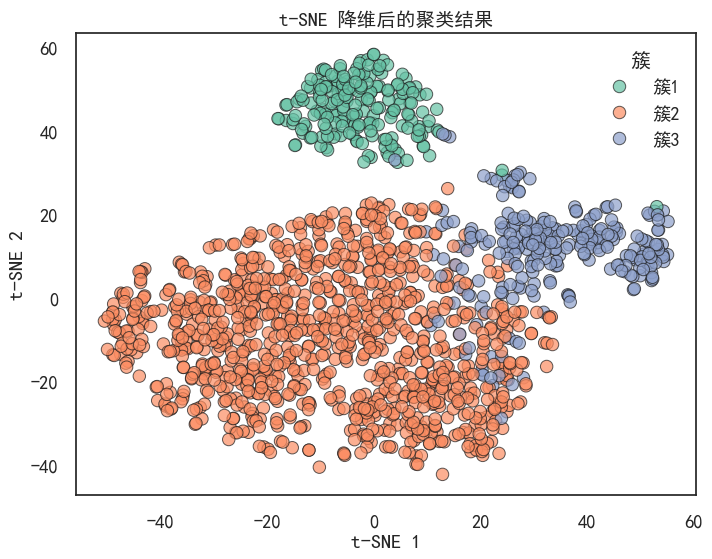

In [ ]:
from sklearn.manifold import TSNE

# 簇编号转换（内部0-based，显示1-based）
df_selected["Cluster"] = cluster_labels + 1

# ========== t-SNE 降维可视化 ==========
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200, n_iter=1000)
X_tsne = tsne.fit_transform(X_processed)

# 构造 hue 标签 & 排序（1-based）
cluster_labels_str = [f"簇{i}" for i in df_selected["Cluster"]]
hue_order = [f"簇{i}" for i in sorted(df_selected["Cluster"].unique())]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=cluster_labels_str,
    hue_order=hue_order,
    palette="Set2", s=80, alpha=0.7, edgecolor="k"
)
plt.title("t-SNE 降维后的聚类结果", fontsize=14)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="簇", loc="best")
plt.savefig(os.path.join(output_dir, "tSNE聚类结果.png"), dpi=300, bbox_inches="tight")
plt.show()




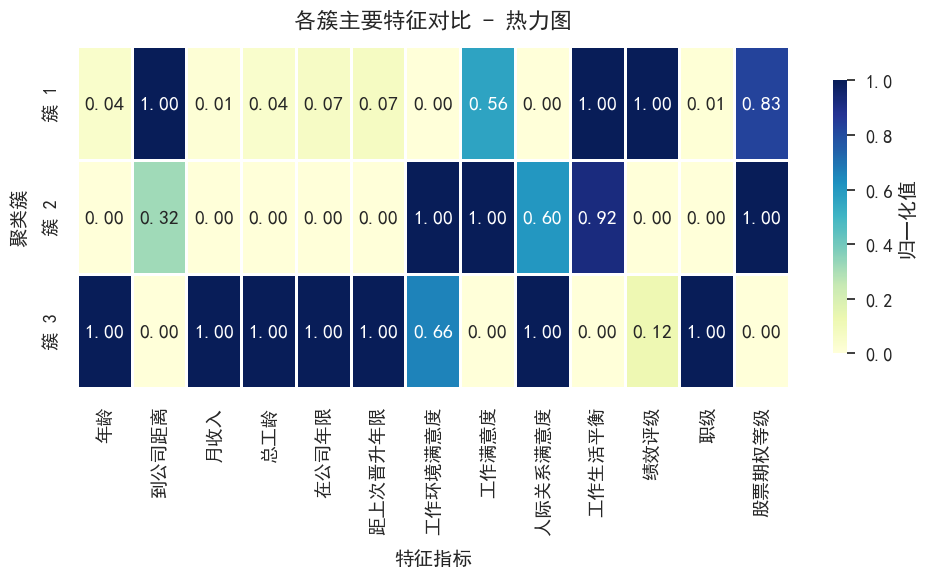

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# 模拟数据：替换成你的 radar_data_norm
# radar_data_norm 行=簇编号，列=特征，值已归一化
# radar_data_norm = your_data

heatmap_data = radar_data_norm.copy()
heatmap_data.index = [f"簇 {i}" for i in heatmap_data.index]
heatmap_data.columns = [feature_name_map.get(c, c) for c in heatmap_data.columns]  # 中文映射

# Nature 风格参数
sns.set_theme(style="white", font_scale=1.2)
plt.rcParams['font.sans-serif'] = ['SimHei']  # 支持中文
plt.rcParams['axes.unicode_minus'] = False

# 绘制热力图
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    annot=True,          # 在格子内标注数值
    fmt=".2f",           # 数值小数位
    cmap="YlGnBu",       # 柔和的黄-绿-蓝渐变，Nature 风格常用
    linewidths=0.8,      # 格子分割线宽度
    linecolor="white",   # 分割线颜色
    cbar_kws={"shrink": 0.8, "label": "归一化值"}  # 颜色条配置
)

# 美化标题和标签
ax.set_title("各簇主要特征对比 - 热力图", fontsize=16, pad=14, weight='bold')
ax.set_xlabel("特征指标", fontsize=14, labelpad=10)
ax.set_ylabel("聚类簇", fontsize=14, labelpad=10)

# 去掉多余边框
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "簇特征热力图_Nature风格.png"), dpi=300, bbox_inches="tight")
plt.show()


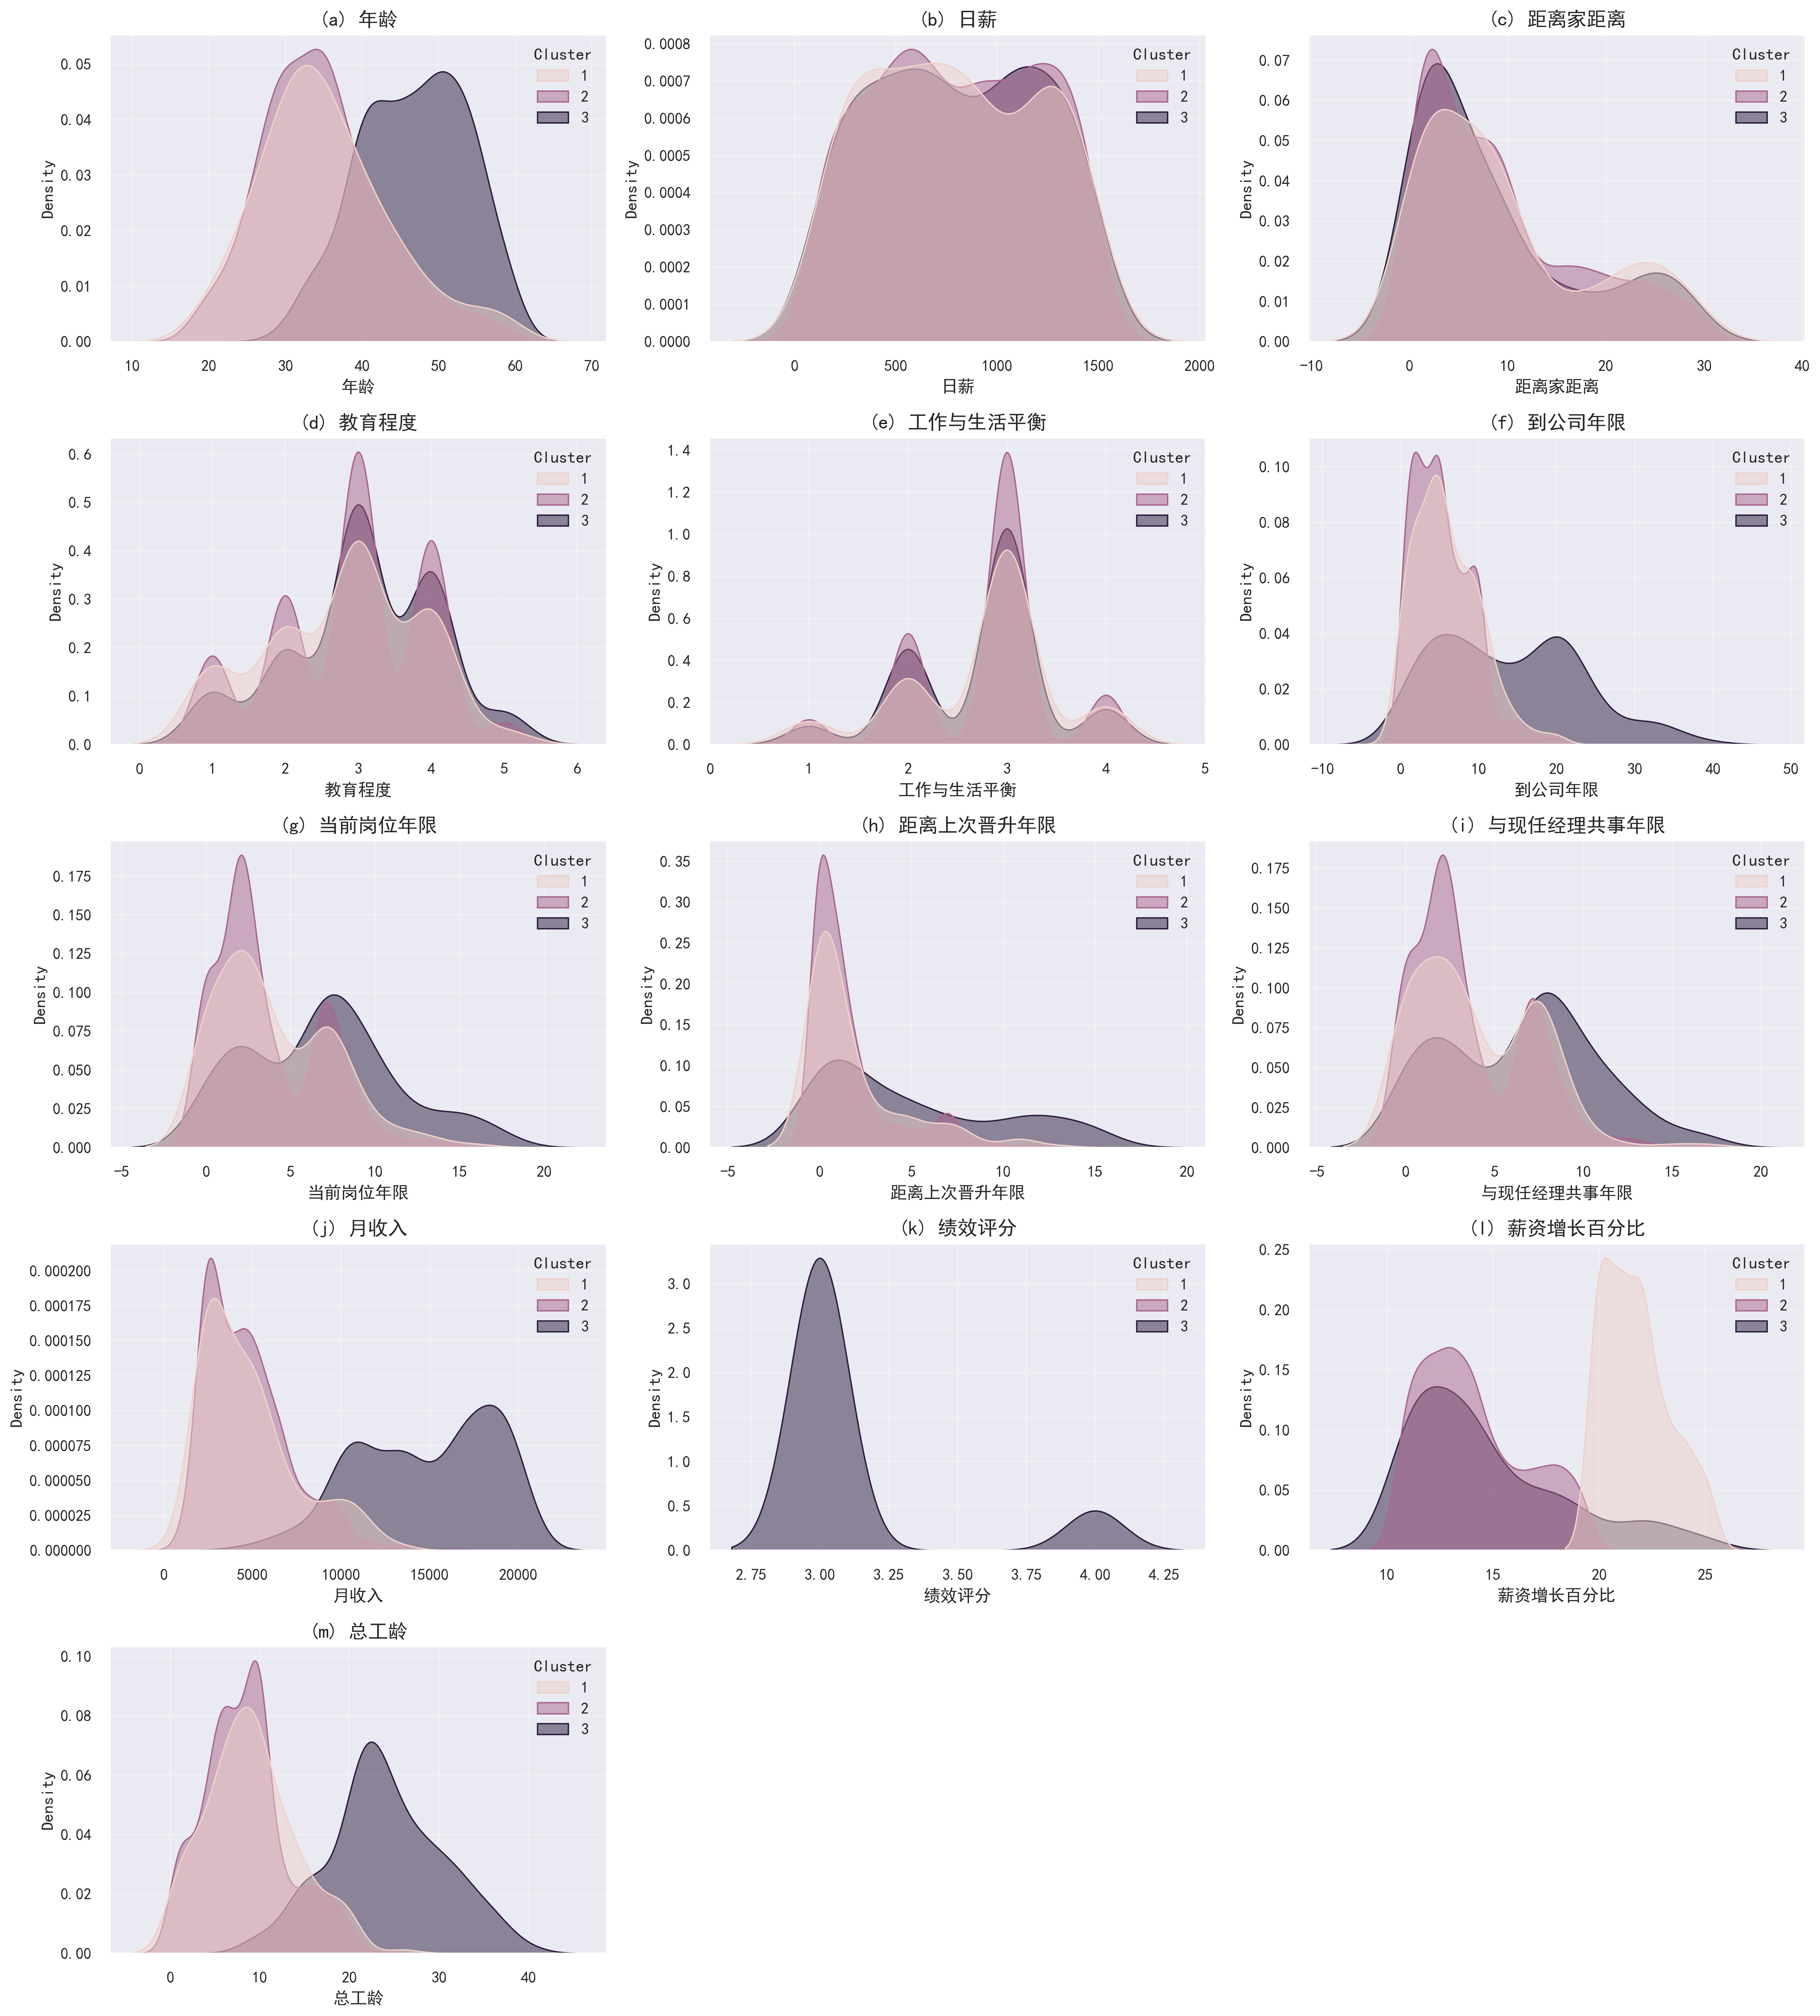

✅ 已生成带编号的附录图：附录_簇特征分布对比_13特征_编号版.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import string  # 用于生成 a, b, c...

# 中文显示
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 核心特征
核心特征 = [
    "年龄",
    "日薪",
    "距离家距离",
    "教育程度",
    "工作与生活平衡",
    "到公司年限",
    "当前岗位年限",
    "距离上次晋升年限",
    "与现任经理共事年限",
    "月收入",
    "绩效评分",
    "薪资增长百分比",
    "总工龄"
]

# 检查缺失列
缺失列 = [f for f in 核心特征 if f not in df.columns]
if 缺失列:
    raise KeyError(f"❌ 数据中缺失以下特征: {缺失列}")

# 子图布局
n_features = len(核心特征)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), dpi=300)
axes = axes.flatten()

# 编号标签 (a) (b) (c) ...
labels = list(string.ascii_lowercase)  # ['a', 'b', 'c', ...]
for i, feature in enumerate(核心特征):
    ax = axes[i]
    sns.kdeplot(
        data=df,
        x=feature,
        hue="Cluster",
        fill=True,
        common_norm=False,
        alpha=0.5,
        ax=ax
    )
    ax.set_title(f"({labels[i]}) {feature}", fontsize=14)  # 添加编号
    ax.grid(alpha=0.3)

# 删除多余空子图
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("附录_簇特征分布对比_13特征_编号版.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ 已生成带编号的附录图：附录_簇特征分布对比_13特征_编号版.png")


In [ ]:
# 自动补充 Cluster 列（仅在不存在时）
if "Cluster" not in df.columns:
    try:
        df["Cluster"] = cluster_labels + 1
    except NameError:
        raise ValueError("❌ 请先运行聚类算法并生成 cluster_labels 变量")


In [ ]:
print(df.columns)
df.head()

Index(['年龄', 'Attrition', 'BusinessTravel', '日薪', 'Department', '距离家距离',
       '教育程度', 'EducationField', '员工计数', '员工编号', '工作环境满意度', 'Gender', '时薪',
       '工作投入度', '岗位等级', 'JobRole', '工作满意度', 'MaritalStatus', '月收入', '月薪率',
       '曾工作公司数', 'Over18', 'OverTime', '薪资增长百分比', '绩效评分', '关系满意度', '标准工时',
       '股票期权等级', '总工龄', '去年培训次数', '工作与生活平衡', '到公司年限', '当前岗位年限', '距离上次晋升年限',
       '与现任经理共事年限', 'Cluster'],
      dtype='object')


,年龄,Attrition,BusinessTravel,日薪,Department,距离家距离,教育程度,EducationField,员工计数,员工编号,...,标准工时,股票期权等级,总工龄,去年培训次数,工作与生活平衡,到公司年限,当前岗位年限,距离上次晋升年限,与现任经理共事年限,Cluster
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,80,0,8,0,1,6,4,0,5,2
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,80,1,10,3,3,10,7,1,7,1
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,80,0,7,3,3,0,0,0,0,2
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,80,0,8,3,3,8,7,3,0,2
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,80,1,6,3,3,2,2,2,2,2


# 第五步：多模型训练、评估与对比


1. 训练多个分类模型：我们将选择几个经典且性能优秀的模型，如逻辑回归、随机森林、梯度提升树(LightGBM)等。
2. 评估模型性能：使用多个经典指标（准确率、精确率、召回率、F1分数、AUC）在测试集上评估每个模型。
3. 绘制模型对比图：用条形图直观地比较不同模型在各项指标上的表现。
4. 寻找最佳阈值：对于表现最好的模型，我们将绘制P-R曲线和ROC曲线，并展示如何通过调整分类阈值来优化特定指标（如F1分数）。

## 4.1: 模型训练与评估

我们将定义、训练和评估4个广泛使用的模型：

1. 逻辑回归（LogisticRegression）
2. 支持向量机（SVC）
3. XGBoost（XGBClassifier）
4. LightGBM（LGBMClassifier）

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

# 1. 读取原始数据
data_path = r"data/WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(data_path)

# 如果 Attrition 是 Yes/No，映射为0/1
if df["Attrition"].dtype == "object":
    df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

# 2. 定义有序类别特征（Ordinal）
ordinal_features = {
    "Education": [1, 2, 3, 4, 5],   # 教育程度
    "PerformanceRating": [1, 2, 3, 4],  # 绩效评级
    "WorkLifeBalance": [1, 2, 3, 4],    # 工作与生活平衡
    "JobSatisfaction": [1, 2, 3, 4],    # 工作满意度
    "EnvironmentSatisfaction": [1, 2, 3, 4]  # 环境满意度
}

# 3. 特征类型划分
ordinal_cat_features = [c for c in ordinal_features.keys() if c in df.columns]
num_features = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and c not in ordinal_cat_features and c != "Attrition"]
nominal_cat_features = [c for c in df.select_dtypes(include=["object"]).columns if c not in ordinal_cat_features and c != "Attrition"]

# 4. 预处理器（编码 + 标准化）
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

ordinal_transformer = Pipeline(steps=[
    ('ord_encoder', OrdinalEncoder(categories=[ordinal_features[col] for col in ordinal_cat_features]))
])

nominal_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_features),
    ('ord', ordinal_transformer, ordinal_cat_features),
    ('nom', nominal_transformer, nominal_cat_features)
])

# 5. 特征选择（聚类用全特征：数值 + 类别）
X = df[num_features + ordinal_cat_features + nominal_cat_features]
X_processed = preprocessor.fit_transform(X)

# 6. KMeans 聚类
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_processed)

# 7. 将 Cluster 列加回原数据
df["Cluster"] = cluster_labels

# 8. 保存预处理后的数据（全特征 + 聚类标签）
output_path = "data/HR_with_cluster.csv"
df.to_csv(output_path, index=False, encoding="utf-8-sig")
print(f"✅ 预处理完成！已保存到：{output_path}")

print("数值特征:", num_features)
print("有序类别特征:", ordinal_cat_features)
print("无序类别特征:", nominal_cat_features)


✅ 预处理完成！已保存到：data/HR_with_cluster.csv
数值特征: ['Age', 'DailyRate', 'DistanceFromHome', 'EmployeeCount', 'EmployeeNumber', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
有序类别特征: ['Education', 'PerformanceRating', 'WorkLifeBalance', 'JobSatisfaction', 'EnvironmentSatisfaction']
无序类别特征: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score, roc_auc_score, make_scorer

# ===== 1. 读取数据 =====
df = pd.read_csv("data/HR_with_cluster.csv", encoding="utf-8-sig")

target = 'Attrition'

# 数值特征（你上条消息提到的）
numeric_features = ['Age', 'DailyRate', 'DistanceFromHome', 'EmployeeCount',
                    'EmployeeNumber', 'HourlyRate', 'JobInvolvement', 'JobLevel',
                    'MonthlyIncome', 'PerformanceRating', 'WorkLifeBalance',
                    'JobSatisfaction', 'EnvironmentSatisfaction', 'Cluster']  # 加聚类列

# 无序类别特征
nominal_features = ['BusinessTravel', 'Department', 'EducationField', 'Gender',
                    'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

# 有序类别特征（如果有的话，这里示例几个）
# 假设 'Education' 1-5 是有序等级
ordinal_features = []
ordinal_categories = []  # 如果有就填 [[1,2,3,4,5], ...]

# 删除不参与建模的 ID 类字段
drop_cols = [col for col in ['EmployeeNumber'] if col in df.columns]

X = df.drop(columns=[target] + drop_cols)
y = df[target]

# ===== 2. 定义预处理器 =====
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

nominal_transformer = OneHotEncoder(handle_unknown='ignore')

if ordinal_features:
    ordinal_transformer = OrdinalEncoder(categories=ordinal_categories)
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('nom', nominal_transformer, nominal_features),
            ('ord', ordinal_transformer, ordinal_features)
        ]
    )
else:
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('nom', nominal_transformer, nominal_features)
        ]
    )

# ===== 3. 定义模型 =====
models = [
    ('逻辑回归', LogisticRegression(max_iter=500, solver='liblinear')),
    ('随机森林', RandomForestClassifier(n_estimators=200, random_state=42)),
    ('梯度提升树', GradientBoostingClassifier(random_state=42)),
    ('LightGBM', LGBMClassifier(random_state=42)),
    ('XGBoost', XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42)),
    ('支持向量机', SVC(probability=True, kernel='rbf', random_state=42)),
    ('K近邻', KNeighborsClassifier(n_neighbors=5))
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'AUC': make_scorer(roc_auc_score, needs_proba=True),
    'F1': make_scorer(f1_score)
}

results = []

# ===== 4. 多模型交叉验证 =====
for name, clf in models:
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', clf)])
    auc_scores = cross_val_score(pipe, X, y, cv=cv, scoring=scoring['AUC'])
    f1_scores = cross_val_score(pipe, X, y, cv=cv, scoring=scoring['F1'])
    results.append({
        '模型': name,
        'AUC均值': np.mean(auc_scores),
        'AUC标准差': np.std(auc_scores),
        'F1均值': np.mean(f1_scores),
        'F1标准差': np.std(f1_scores)
    })

# ===== 5. Stacking模型 =====
estimators = [(name, Pipeline(steps=[('preprocessor', preprocessor), ('model', clf)])) for name, clf in models if name != '逻辑回归']

# 注意：StackingClassifier 不能直接使用带预处理的 Pipeline 作为第一层？可以，但要包一层 FunctionTransformer
# 此处为了简化，直接在第一层先编码数据，也可以手动编码后传给 Stacking

stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=500),
    cv=cv,
    n_jobs=-1
)

auc_scores = cross_val_score(stacking_model, X, y, cv=cv, scoring=scoring['AUC'])
f1_scores = cross_val_score(stacking_model, X, y, cv=cv, scoring=scoring['F1'])

results.append({
    '模型': 'Stacking集成',
    'AUC均值': np.mean(auc_scores),
    'AUC标准差': np.std(auc_scores),
    'F1均值': np.mean(f1_scores),
    'F1标准差': np.std(f1_scores)
})

# ===== 6. 输出结果 =====
df_results = pd.DataFrame(results)
print(df_results)

# ===== 7. 可视化 =====
plt.figure(figsize=(8, 6))
sns.barplot(x='AUC均值', y='模型', data=df_results, palette='viridis')
plt.title('模型AUC表现对比', fontsize=16)
plt.xlabel('AUC均值')
plt.ylabel('模型')
plt.tight_layout()
plt.savefig("模型AUC对比.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 6))
sns.barplot(x='F1均值', y='模型', data=df_results, palette='magma')
plt.title('模型F1表现对比', fontsize=16)
plt.xlabel('F1均值')
plt.ylabel('模型')
plt.tight_layout()
plt.savefig("模型F1对比.png", dpi=300, bbox_inches="tight")
plt.show()


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "e:\Anaconda\envs\dl\lib\site-packages\pandas\core\indexes\base.py", line 3812, in get_loc
    return self._engine.get_loc(casted_key)
  File "pandas/_libs/index.pyx", line 167, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/index.pyx", line 196, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/hashtable_class_helper.pxi", line 7088, in pandas._libs.hashtable.PyObjectHashTable.get_item
  File "pandas/_libs/hashtable_class_helper.pxi", line 7096, in pandas._libs.hashtable.PyObjectHashTable.get_item
KeyError: 'EmployeeNumber'

The above exception was the direct cause of the following exception:

Traceback (

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve

# 初始化模型
models = {
    "逻辑回归": LogisticRegression(random_state=42, max_iter=1000),
    "随机森林": RandomForestClassifier(random_state=42),
    "LightGBM": lgb.LGBMClassifier(random_state=42)
}

# 存储评估结果的字典
results = {}

# 循环训练和评估每个模型
for name, model in models.items():
    # 训练模型
    model.fit(X_train_smote, y_train_smote)
    
    # 在测试集上进行预测
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] # 获取正类的概率
    
    # 计算评估指标
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    # 存储结果
    results[name] = {
        "准确率": acc,
        "精确率": precision,
        "召回率": recall,
        "F1分数": f1,
        "AUC": auc
    }
    
    print(f"--- {name} 模型评估结果 ---")
    print(f"准确率: {acc:.4f}")
    print(f"精确率: {precision:.4f}")
    print(f"召回率: {recall:.4f}")
    print(f"F1分数: {f1:.4f}")
    print(f"AUC: {auc:.4f}\n")

# 将结果转换为DataFrame，方便绘图
results_df = pd.DataFrame(results).T # .T 表示转置，让模型名作为行索引


--- 逻辑回归 模型评估结果 ---
准确率: 0.7891
精确率: 0.3846
召回率: 0.5319
F1分数: 0.4464
AUC: 0.7188

--- 随机森林 模型评估结果 ---
准确率: 0.8231
精确率: 0.4000
召回率: 0.2128
F1分数: 0.2778
AUC: 0.7383

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 986, number of negative: 986
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000316 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1152
[LightGBM] [Info] Number of data points in the train set: 1972, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
--- LightGBM 模型评估结果 ---
准确率: 0.8469
精确率: 0.5357
召回率: 0.3191
F1分数: 0.4000
AUC: 0.7651



## 4.2: 模型性能对比条形图

现在，我们将使用上一步得到的 results_df 来绘制一个清晰的条形图，横向对比所有模型在不同指标上的表现。

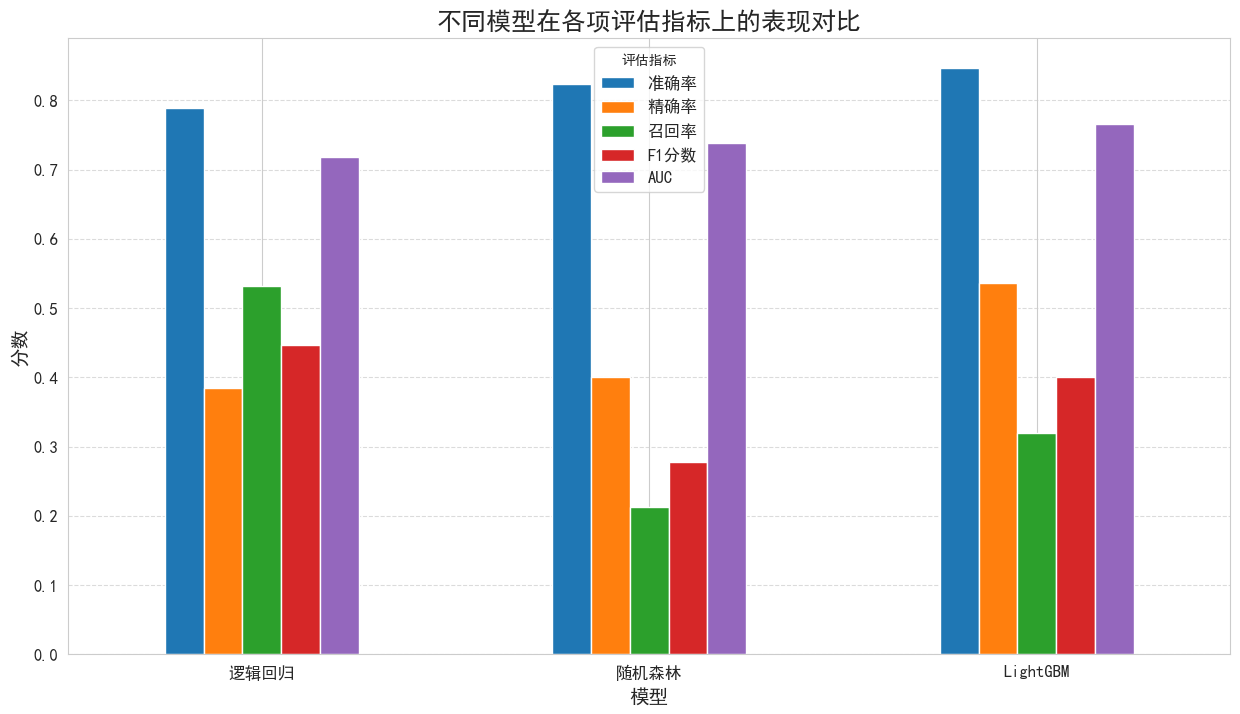

In [ ]:
# 绘制模型评估指标对比图
results_df.plot(kind='bar', figsize=(15, 8), rot=0) # rot=0让x轴标签水平显示

plt.title('不同模型在各项评估指标上的表现对比', fontsize=18)
plt.ylabel('分数', fontsize=14)
plt.xlabel('模型', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='评估指标', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## 4.3: 调整阈值对模型性能的影响

分类模型的 predict() 方法默认使用 0.5 作为阈值。但这个阈值不一定是最优的。我们可以通过分析 精确率-召回率曲线 (Precision-Recall Curve) 来找到一个更好的阈值，以平衡精确率和召回率（即优化F1分数）。

我们将以表现通常最好的 LightGBM 模型为例。

LightGBM 模型: 使得F1分数最大的最佳阈值为 0.1572，此时F1分数为 0.4348


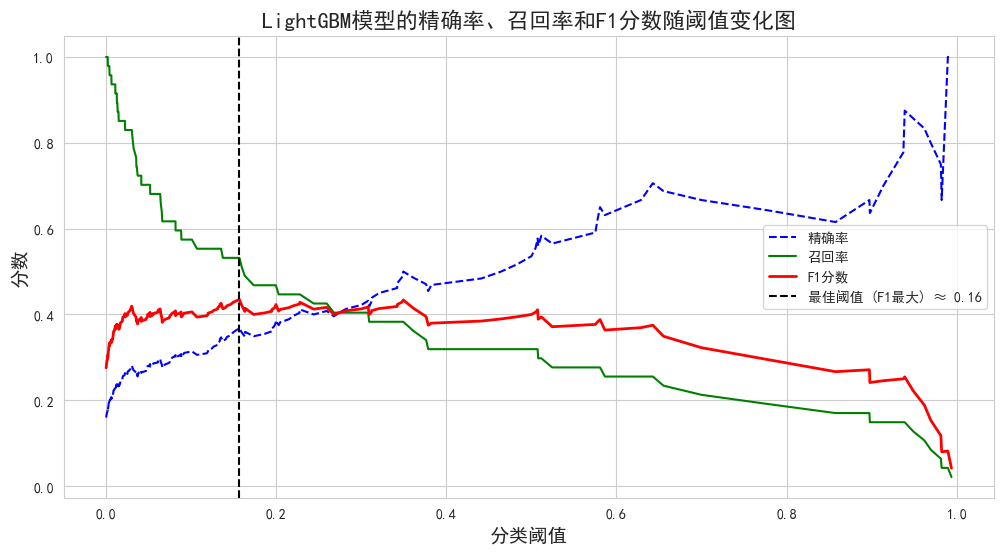

In [ ]:
# 选择LightGBM模型进行分析
best_model_name = "LightGBM"
best_model = models[best_model_name]

# 获取测试集的预测概率
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

# 计算P-R曲线所需的值
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_pred_proba_best)

# 计算不同阈值下的F1分数
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
# 修正f1_scores的计算，避免除以零
f1_scores = np.nan_to_num(f1_scores)

# 找到使F1分数最大的阈值
best_threshold_f1 = thresholds_pr[np.argmax(f1_scores)]
best_f1_score = np.max(f1_scores)

print(f"LightGBM 模型: 使得F1分数最大的最佳阈值为 {best_threshold_f1:.4f}，此时F1分数为 {best_f1_score:.4f}")

# 绘制阈值影响图
plt.figure(figsize=(12, 6))
plt.plot(thresholds_pr, precisions[:-1], 'b--', label='精确率')
plt.plot(thresholds_pr, recalls[:-1], 'g-', label='召回率')
plt.plot(thresholds_pr, f1_scores[:-1], 'r-', label='F1分数', linewidth=2)
plt.axvline(x=best_threshold_f1, color='k', linestyle='--', label=f'最佳阈值 (F1最大) ≈ {best_threshold_f1:.2f}')

plt.title('LightGBM模型的精确率、召回率和F1分数随阈值变化图', fontsize=16)
plt.xlabel('分类阈值', fontsize=14)
plt.ylabel('分数', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()


数据不平衡问题太严重了，建议忽略掉阈值调参这一步

# 第五步：模型 Stacking 融合
Stacking 是一种强大的集成学习技术。它的核心思想是：用一个模型去学习如何更好地组合其他多个模型的预测结果。
1. 基模型 (Base Models)：选择之前表现较好的两个模型——随机森林和逻辑回归。
2. 元模型 (Meta Model)：选择表现最好的模型——LightGBM。
3. 训练过程：
    - 在训练集上通过交叉验证的方式训练基模型。
    - 用基模型对训练集的预测结果作为元模型的新特征。
    - 用基模型对测试集的预测结果作为元模型的新测试特征。
    - 最后，训练元模型，并得出最终的预测结果。
scikit-learn 提供了 StackingClassifier 来方便地实现这个过程。

##  5.1: Stacking 模型构建与评估

In [ ]:
from sklearn.ensemble import StackingClassifier

# --- 1. 定义基模型和元模型 ---
# 我们使用之前已经定义好的模型实例
# 注意：为了让 StackingClassifier 内部能获取到概率预测，
# 我们需要确保基模型支持 predict_proba。
# LogisticRegression, RandomForestClassifier 都支持。
base_estimators = [
    ('随机森林', RandomForestClassifier(random_state=42)),
    ('逻辑回归', LogisticRegression(random_state=42, max_iter=1000))
]

# 元模型
meta_model = lgb.LGBMClassifier(random_state=42)

# --- 2. 构建 Stacking 分类器 ---
# cv=5 表示使用5折交叉验证来生成基模型的预测，作为元模型的训练数据
# passthrough=True 表示原始特征也会被传递给元模型，这通常能提升性能
stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_model,
    cv=5,
    stack_method='predict_proba', # 让基模型输出概率，信息更丰富
    passthrough=True 
)

# --- 3. 训练 Stacking 模型 ---
# Stacking模型也应该在平衡后的数据上训练
print("开始训练 Stacking 模型...")
stacking_model.fit(X_train_smote, y_train_smote)
print("Stacking 模型训练完成。")

# --- 4. 评估 Stacking 模型 ---
y_pred_stack = stacking_model.predict(X_test)
y_pred_proba_stack = stacking_model.predict_proba(X_test)[:, 1]

# 计算评估指标
acc_stack = accuracy_score(y_test, y_pred_stack)
precision_stack = precision_score(y_test, y_pred_stack)
recall_stack = recall_score(y_test, y_pred_stack)
f1_stack = f1_score(y_test, y_pred_stack)
auc_stack = roc_auc_score(y_test, y_pred_proba_stack)

# 将 Stacking 模型的结果添加到之前的 results_df 中，方便对比
results_df.loc['Stacking融合模型'] = [acc_stack, precision_stack, recall_stack, f1_stack, auc_stack]

print("\n--- Stacking融合模型 评估结果 ---")
print(f"准确率: {acc_stack:.4f}")
print(f"精确率: {precision_stack:.4f}")
print(f"召回率: {recall_stack:.4f}")
print(f"F1分数: {f1_stack:.4f}")
print(f"AUC: {auc_stack:.4f}\n")

# 显示更新后的结果表格
print("--- 所有模型评估结果对比 ---")
print(results_df)



开始训练 Stacking 模型...
[LightGBM] [Info] Number of positive: 986, number of negative: 986
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000624 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1507
[LightGBM] [Info] Number of data points in the train set: 1972, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Stacking 模型训练完成。

--- Stacking融合模型 评估结果 ---
准确率: 0.8435
精确率: 0.5185
召回率: 0.2979
F1分数: 0.3784
AUC: 0.7354

--- 所有模型评估结果对比 ---
                   准确率       精确率       召回率      F1分数       AUC
逻辑回归          0.789116  0.384615  0.531915  0.446429  0.718753
随机森林          0.823129  0.400000  0.212766  0.277778  0.738306
LightGBM      0.846939  0.535714  0.319149  0.400000  0.765096
Stacking融合模型  0.843537  0.518519  0.297872  0.378378  0.735378


## 5.2: 最终模型对比图 (包含Stacking模型)

现在我们重新绘制对比图，将 Stacking 模型也包含进来，看看它是否超越了任何单一模型。

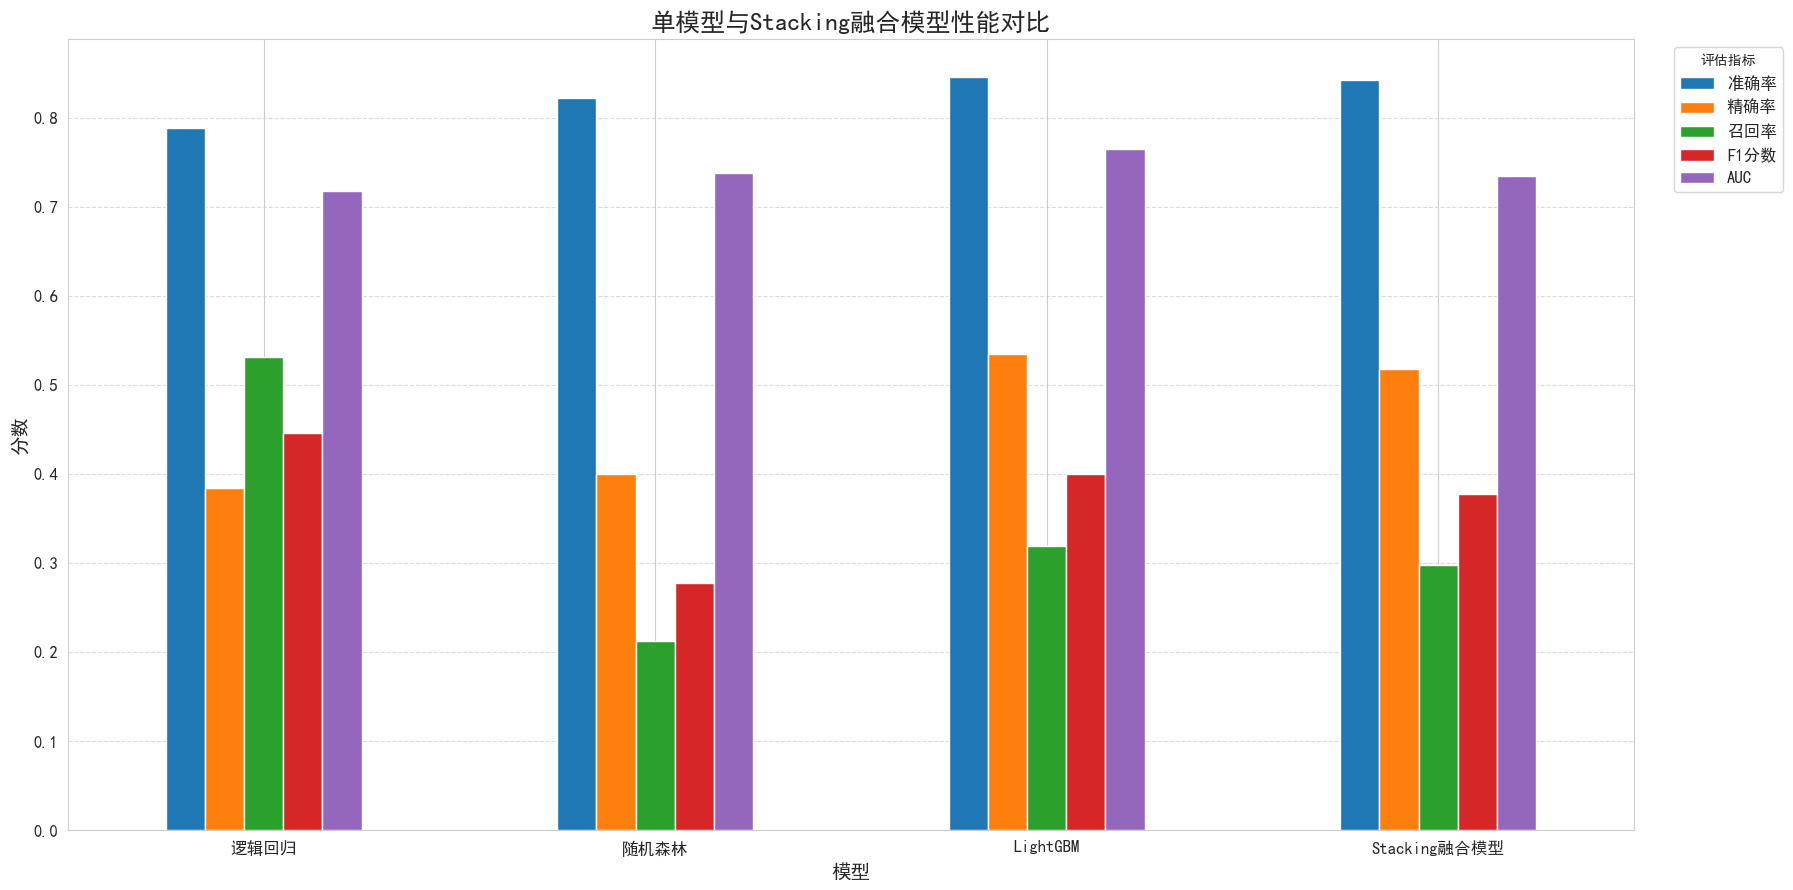

In [ ]:
# 绘制包含 Stacking 模型的评估指标对比图
results_df.plot(kind='bar', figsize=(18, 9), rot=0)

plt.title('单模型与Stacking融合模型性能对比', fontsize=18)
plt.ylabel('分数', fontsize=14)
plt.xlabel('模型', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='评估指标', fontsize=12, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



不要放这个图了，自己放一个表把故事说圆了就好

# 第六步：使用 SHAP 进行模型解释
SHAP (SHapley Additive exPlanations) 是一个强大的工具，它能解释任何机器学习模型的输出。它基于博弈论中的 Shapley 值，可以告诉我们每个特征对模型的单次预测或整体预测贡献了多少。这对于理解“模型为什么会做出这样的决策”至关重要，也是向老师汇报时的绝佳内容。

我们将使用之前性能最好的单一模型 LightGBM 来进行解释，因为树模型与 SHAP 的结合效率最高且效果最好。



##  6.1: 安装 SHAP 并初始化解释器

首先，确保 SHAP 库已安装，并创建一个 Explainer 对象。

In [ ]:
# !pip install shap

import shap

# --- 1. 选择要解释的模型 ---
# 我们选择性能最好的LightGBM模型
model_to_explain = models['LightGBM']

# --- 2. 创建SHAP解释器 ---
# 对于树模型，使用 TreeExplainer 效率最高
explainer = shap.TreeExplainer(model_to_explain)

# --- 3. 计算SHAP值 ---
# 我们在测试集上计算SHAP值，来理解模型在未知数据上的行为
# 注意：SHAP值的计算可能需要一些时间
print("正在计算测试集的 SHAP 值...")
shap_values = explainer.shap_values(X_test)
print("SHAP 值计算完成。")


# --- 4. 确认SHAP值的形状和类型 ---
# 新版本SHAP对于LightGBM二分类器的输出格式有所改变
# 现在返回的是一个数组，而不是列表
print(f"SHAP值的类型: {type(shap_values)}")
print(f"SHAP值的形状: {shap_values.shape}")

# 对于二分类问题，我们直接使用返回的SHAP值
# 这些值表示对正类（离职）的预测贡献
shap_values_for_attrition = shap_values 


正在计算测试集的 SHAP 值...
SHAP 值计算完成。
SHAP值的类型: <class 'numpy.ndarray'>
SHAP值的形状: (294, 44)


## 6.2: 全局特征重要性图

这张图告诉我们，在全局范围内，哪些特征对模型的预测影响最大。它通过对每个特征的 SHAP 值取平均绝对值来排序。

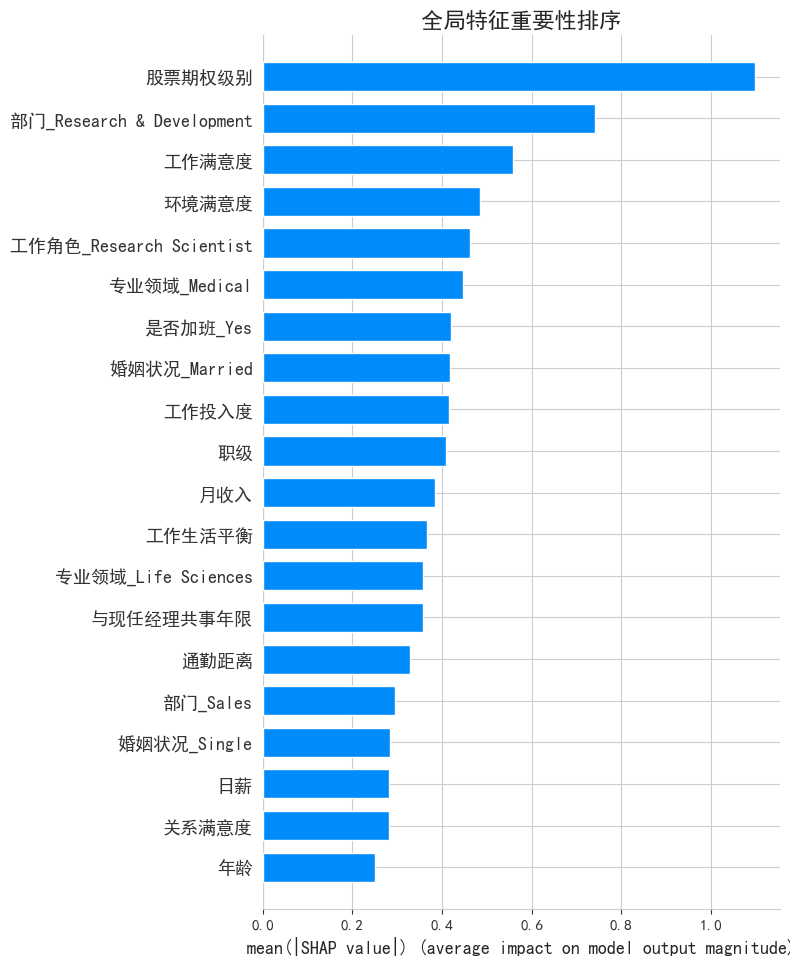

In [ ]:
# 绘制全局特征重要性图 (条形图)
# shap.summary_plot 传入 plot_type="bar" 即可

shap.summary_plot(shap_values_for_attrition, X_test, plot_type="bar", show=False)

plt.title("全局特征重要性排序", fontsize=16)
plt.show()


## 6.3: SHAP 蜂窝图 (Summary Plot)

这是 SHAP 最具代表性的图。它不仅显示了特征的重要性，还揭示了特征值的大小如何影响预测结果。

1. Y轴：特征，按重要性排序。
2. X轴：SHAP 值。正值表示该特征将预测推向“离职”，负值则推向“不离职”。
3. 颜色：代表特征值的大小。红色表示特征值高，蓝色表示特征值低。

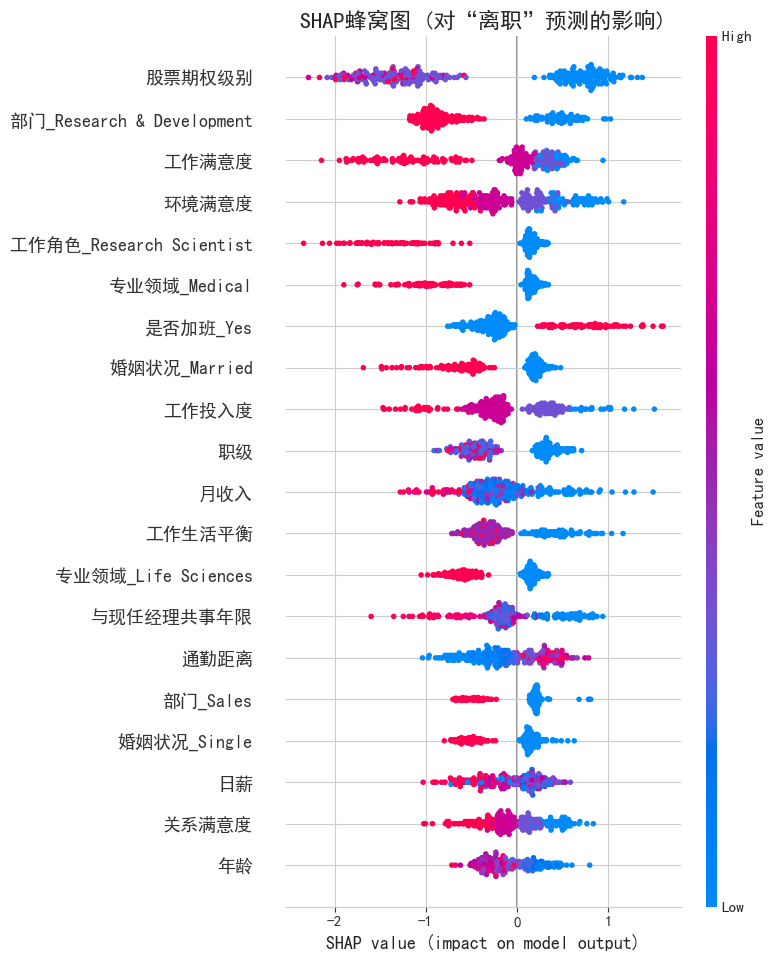

In [ ]:
# 绘制蜂窝图 (Summary Plot)
# 我们只为类别 "1" (离职) 绘制
shap.summary_plot(shap_values_for_attrition, X_test, show=False)

# 获取当前的matplotlib Figure对象并修改标题
# summary_plot 会自动创建图，我们在这里获取并修改它
fig = plt.gcf()
ax = plt.gca()
ax.set_title("SHAP蜂窝图 (对“离职”预测的影响)", fontsize=16)
plt.show()

# 如果您想分别看对两个类的影响，可以这样画：
# print("\n--- 对“不离职”(类别0)的蜂窝图 ---")
# shap.summary_plot(shap_values[0], X_test, title="对“不离职”预测的影响")


## 6.4: 特征依赖图与交互效应图

依赖图可以更深入地展示单个特征如何影响预测。我们还可以通过 interaction_index 自动发现与该特征交互最强的另一个特征，并用颜色表示出来。

我们将为最重要的前3个特征绘制此图。

最重要的3个特征是: ['股票期权级别', '部门_Research & Development', '工作满意度']


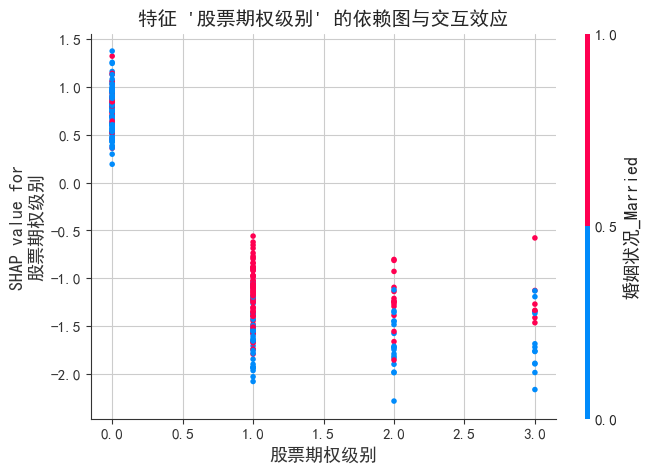

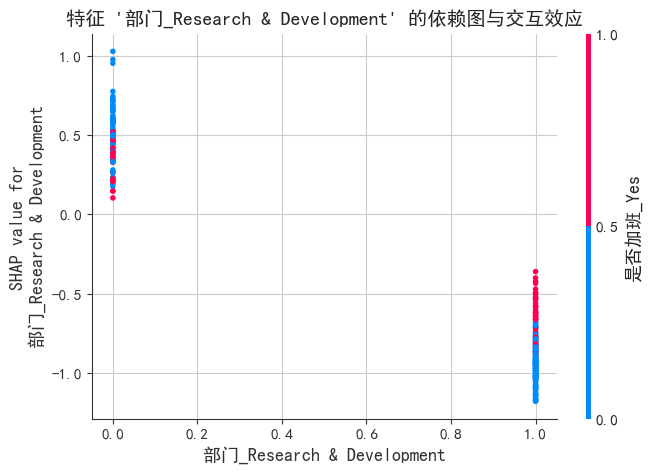

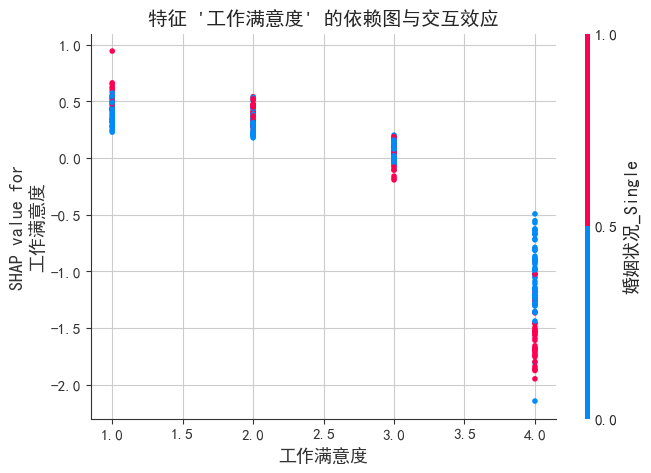

In [ ]:
# 获取最重要的前3个特征的名称
feature_names = X_test.columns
top_3_features = pd.Series(np.abs(shap_values_for_attrition).mean(0), index=feature_names).nlargest(3).index

print(f"最重要的3个特征是: {top_3_features.tolist()}")

for feature in top_3_features:
    # 绘制依赖图，并自动着色显示交互效应最强的特征
    shap.dependence_plot(
        feature, 
        shap_values_for_attrition, 
        X_test, 
        interaction_index="auto", # 自动寻找交互最强的特征
        show=False
    )
    plt.title(f"特征 '{feature}' 的依赖图与交互效应", fontsize=14)
    plt.show()


## 6.5: 单个样本预测解释 (瀑布图)

瀑布图（Waterfall Plot）非常适合解释为什么模型对某一个具体的样本做出如此的预测。它从模型的基准值（平均预测概率）开始，一步步展示每个特征如何将预测推高或拉低，最终得到该样本的最终预测值。

我们随机选择一个模型预测为“离职”的样本和一个预测为“不离职”的样本进行对比。


--- 解释样本 0 (模型预测: 离职) ---


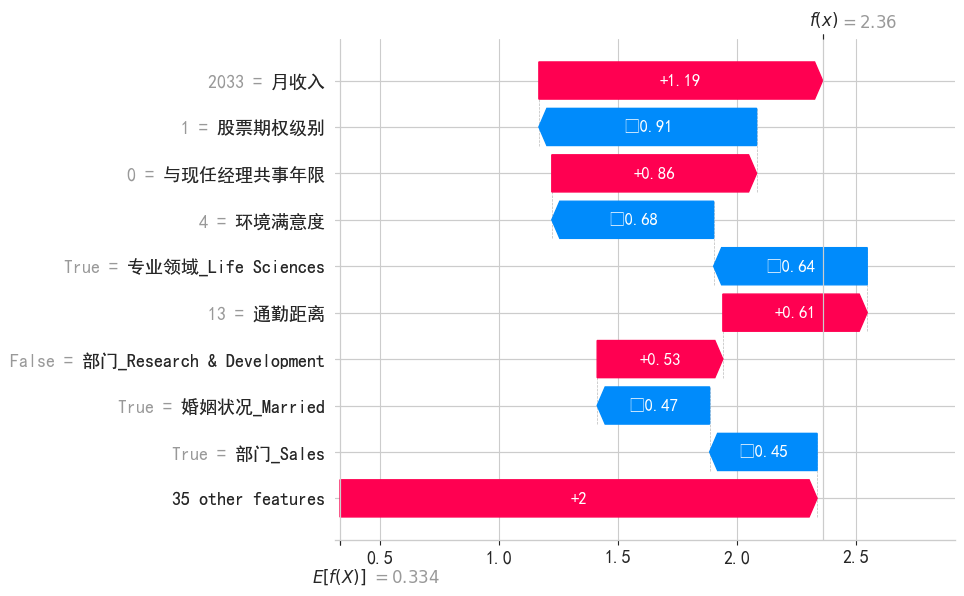


--- 解释样本 1 (模型预测: 不离职) ---


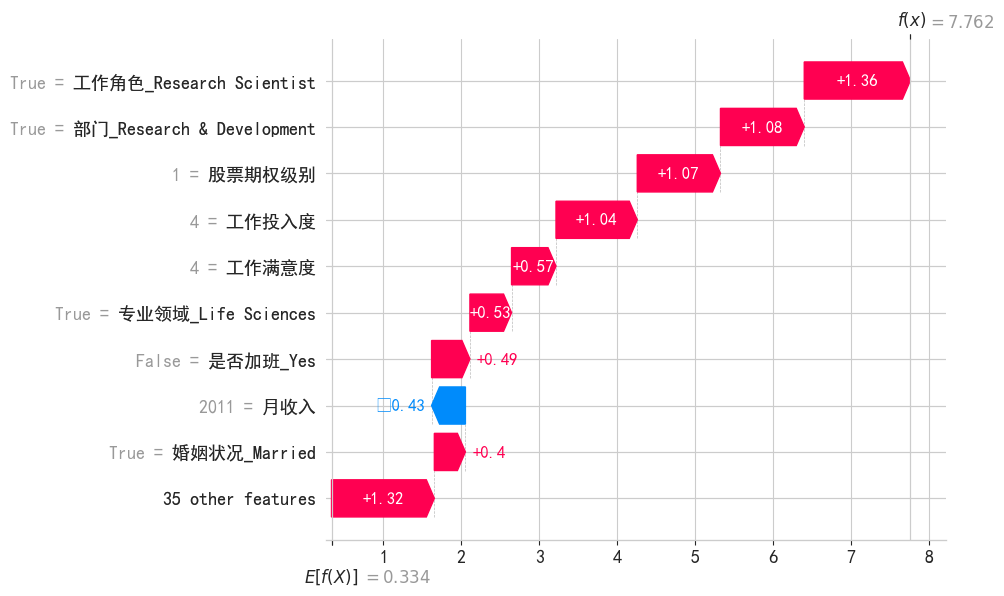

In [ ]:

# 找到一个模型预测为"离职"的样本
predicted_attrition_indices = np.where(model_to_explain.predict(X_test) == 1)[0]
if len(predicted_attrition_indices) > 0:
    sample_index_attrition = predicted_attrition_indices[0] # 取第一个
    print(f"\n--- 解释样本 {sample_index_attrition} (模型预测: 离职) ---")
    
    # 新版本SHAP的expected_value获取方式
    # 对于二分类，直接使用expected_value（不是列表）
    expected_value = explainer.expected_value
    
    shap.waterfall_plot(shap.Explanation(
        values=shap_values_for_attrition[sample_index_attrition],
        base_values=expected_value,
        data=X_test.iloc[sample_index_attrition],
        feature_names=X_test.columns.tolist()
    ))
else:
    print("测试集中没有找到模型预测为'离职'的样本。")


# 找到一个模型预测为"不离职"的样本
predicted_no_attrition_indices = np.where(model_to_explain.predict(X_test) == 0)[0]
if len(predicted_no_attrition_indices) > 0:
    sample_index_no_attrition = predicted_no_attrition_indices[0]
    print(f"\n--- 解释样本 {sample_index_no_attrition} (模型预测: 不离职) ---")
    
    # 对于"不离职"的样本，我们使用负的SHAP值来展示
    expected_value = explainer.expected_value
    
    shap.waterfall_plot(shap.Explanation(
        values=-shap_values_for_attrition[sample_index_no_attrition], # 使用负值来展示对"不离职"的贡献
        base_values=expected_value,
        data=X_test.iloc[sample_index_no_attrition],
        feature_names=X_test.columns.tolist()
    ))
else:
    print("测试集中没有找到模型预测为'不离职'的样本。")

